# Import

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

import joblib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator

In [3]:
pre_path = "../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_B/final_models/"
path_to_predictions = pre_path + "predictions/model_B/final_models/"
path_to_models = 'model/final_models/model_B/PARSEC/'
output_parameters = ['T_eff', 'log_g', 'radius']
categories_name = ["phase"]

In [4]:
override = True
use_preds = False
save = True
show = True

input_col_names = ['$\log(age)$', '$[\mathrm{Fe/H}]$', '$M_\odot$']
output_col_names = ['T_eff', 'log_g', 'radius']

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\o'
C:\Users\antoi\AppData\Local\Temp\ipykernel_27588\2025676495.py:6: SyntaxWarning: invalid escape sequence '\l'
  input_col_names = ['$\log(age)$', '$[\mathrm{Fe/H}]$', '$M_\odot$']
C:\Users\antoi\AppData\Local\Temp\ipykernel_27588\2025676495.py:6: SyntaxWarning: invalid escape sequence '\m'
  input_col_names = ['$\log(age)$', '$[\mathrm{Fe/H}]$', '$M_\odot$']
C:\Users\antoi\AppData\Local\Temp\ipykernel_27588\2025676495.py:6: SyntaxWarning: invalid escape sequence '\o'
  input_col_names = ['$\log(age)$', '$[\mathrm{Fe/H}]$', '$M_\odot$']


# Data preparation

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})

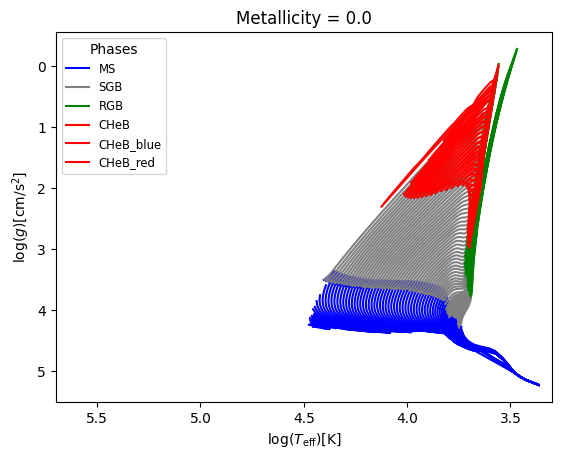

In [7]:
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'metallicity', 'Mass'], 
                               y_cols=['logTe', 'logg', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the logTe parameter : 3.3621 - 4.5177
Median value in train data for the logTe parameter: 3.721
Mean value in train data for the logTe parameter: 3.777965141417156

Range in train data for the logg parameter : -0.384 - 5.345
Median value in train data for the logg parameter: 2.486
Mean value in train data for the logg parameter: 2.761182341921151

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the logTe parameter : 3.3622 - 4.5177
Median value in test data for the logTe parameter: 3.721
Mean value in test data for the logTe parameter: 3.777738115487914

Range in test data for the logg parameter : -0.347 - 5.345
Median value in test data for the logg parameter: 2.486
Mean value in test data for the logg parameter: 2.75

In [9]:
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")
X_train_power, X_ivs_power = Data_preparator.scale_data(X_train, X_ivs, "power")

print(X_train_quantile.shape, X_ivs_quantile.shape)
print(X_train_power.shape, X_ivs_power.shape)

(241272, 3) (80424, 3)
(241272, 3) (80424, 3)


# Getting the final evaluations

## Random forest

In [10]:
tag = "scale_quantile"


scale_quantile train data :
Training the model...
Evaluating predictions...
1.7763568394002505e-15
no negative values

T_eff results for the phase category with a value of 1.0
  value range :  3.3622 - 4.5177
  RVE :  0.980979430158206
  RMSE :  0.03751300297728948
  MAE :  0.009432279765870081
  MedAE :  0.0012364951764034515
  CORR :  0.9905311269394429
  MAX_ER :  0.7933915209735258
  Percentiles : 
    75th percentile :  0.005379087091417767
    90th percentile :  0.019398696263826305
    95th percentile :  0.03932187849052666
    99th percentile :  0.12745114565862284

T_eff results for the phase category with a value of 2.0
  value range :  3.602 - 4.4428
  RVE :  0.914046615989819
  RMSE :  0.051333278795490975
  MAE :  0.031994240689741854
  MedAE :  0.017836598775410772
  CORR :  0.9597359542995163
  MAX_ER :  0.5563682716534135
  Percentiles : 
    75th percentile :  0.04335500496177125
    90th percentile :  0.07889645031975102
    95th percentile :  0.1059226409886329
    

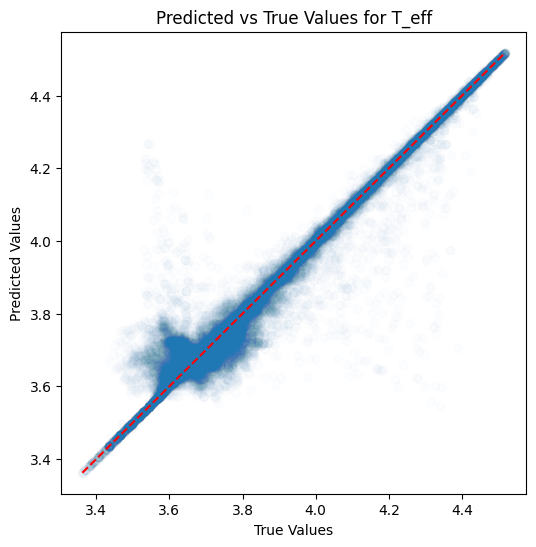

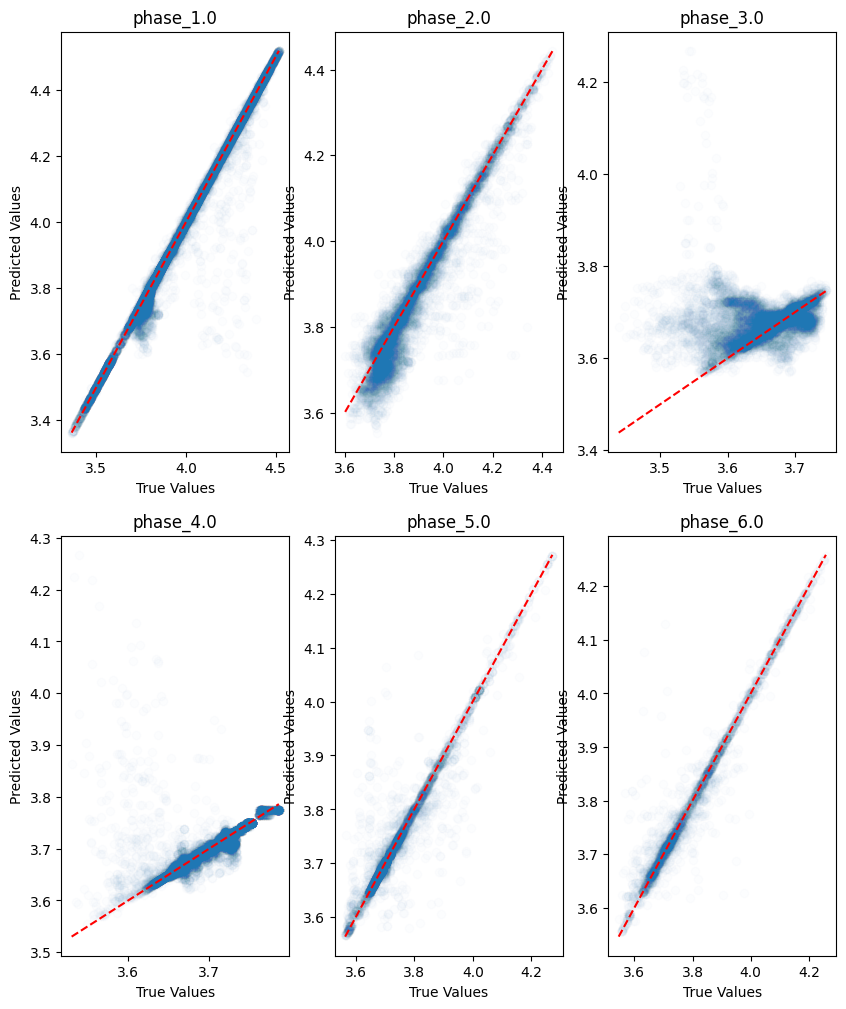

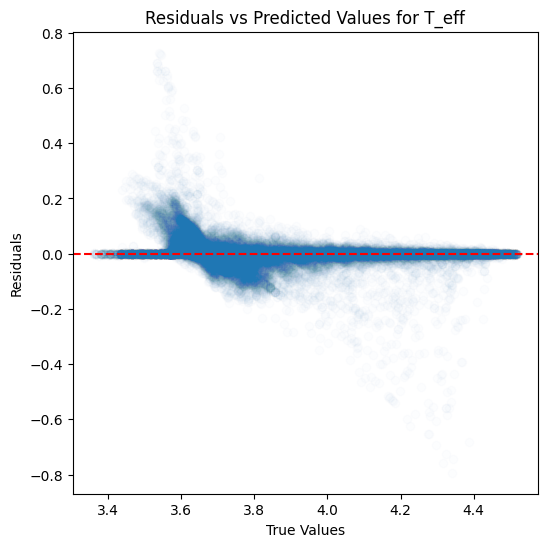

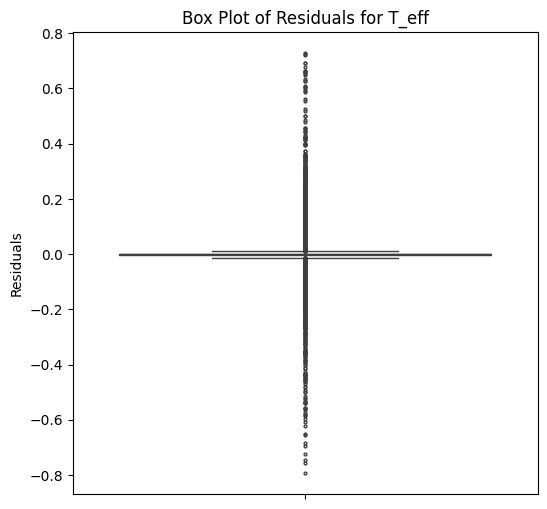

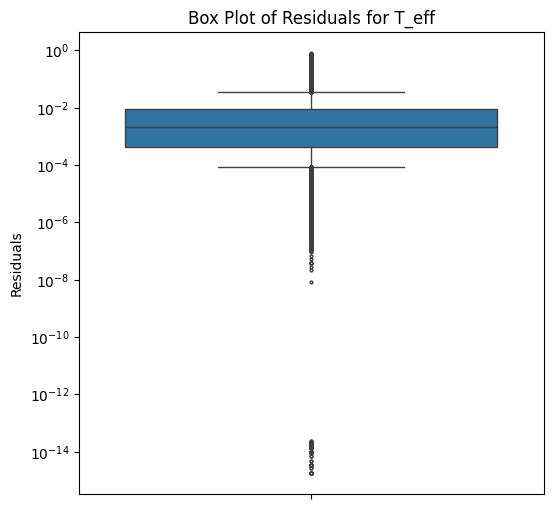

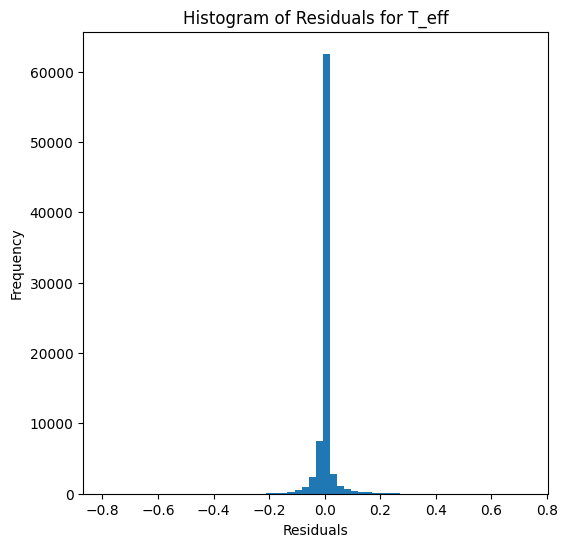

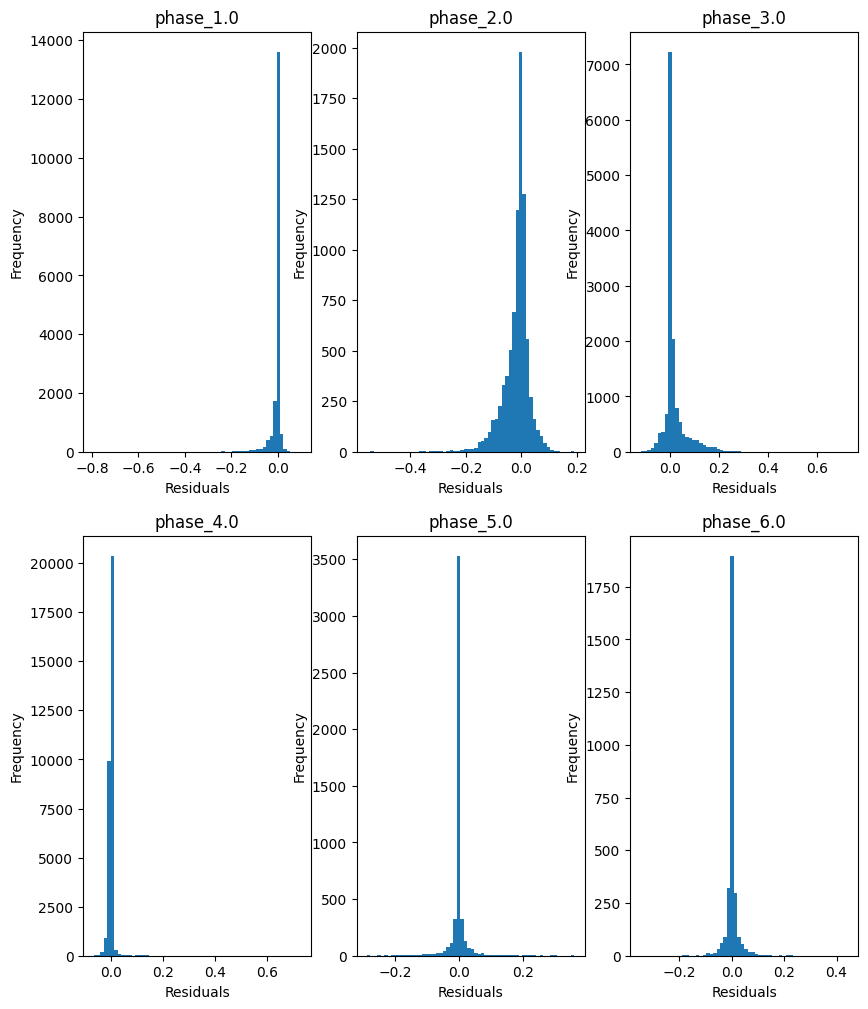

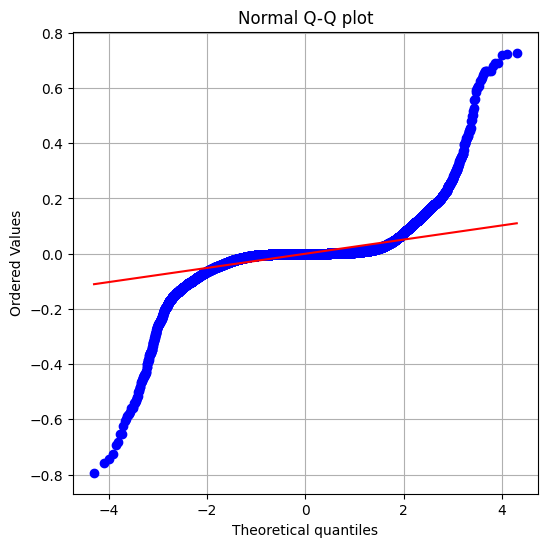

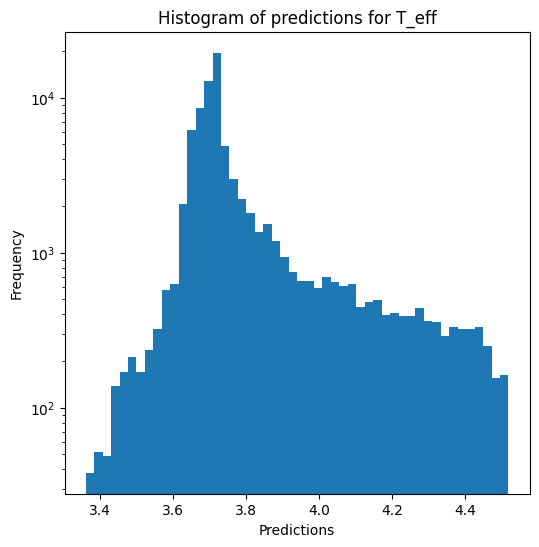

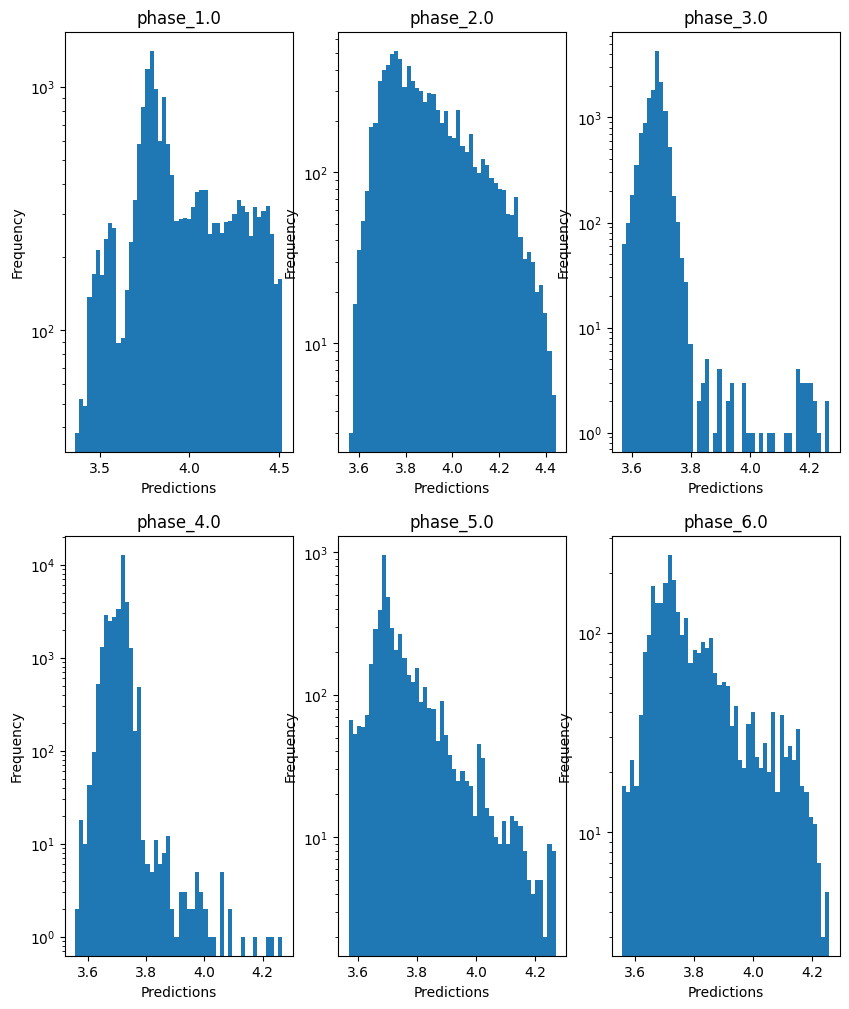

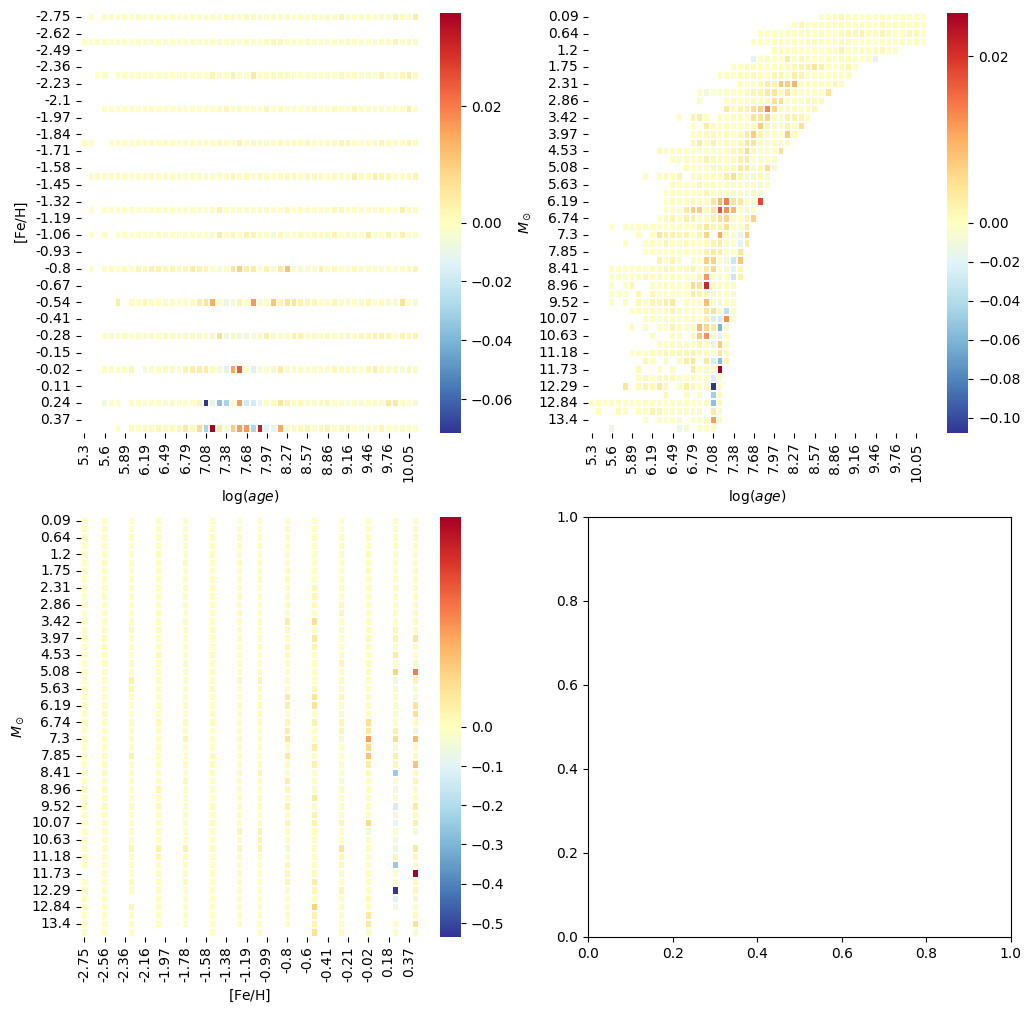

1.1102230246251565e-16

log_g results for the phase category with a value of 1.0
  value range :  3.241 - 5.345
  RVE :  0.28937621101683
  RMSE :  0.2987063335189955
  MAE :  0.08485284326197409
  MedAE :  0.004386470513481289
  CORR :  0.8057401790997997
  MAX_ER :  3.632412478579711
  Percentiles : 
    75th percentile :  0.020109675790731307
    90th percentile :  0.16081804979953976
    95th percentile :  0.5638421626325951
    99th percentile :  1.6553401802243575

log_g results for the phase category with a value of 2.0
  value range :  0.672 - 4.266
  RVE :  0.6402327001537882
  RMSE :  0.5273846053028075
  MAE :  0.2720745294308923
  MedAE :  0.07186650857814114
  CORR :  0.8135120934459463
  MAX_ER :  3.0362490617795106
  Percentiles : 
    75th percentile :  0.23750773257590074
    90th percentile :  0.995179161661133
    95th percentile :  1.3457612517410522
    99th percentile :  1.9323342997813748

log_g results for the phase category with a value of 3.0
  value range :  

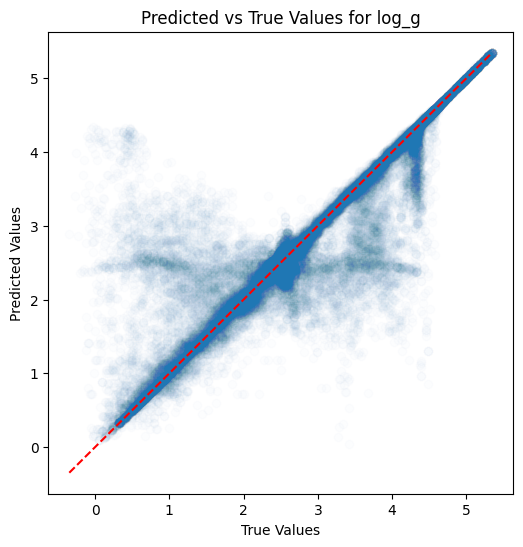

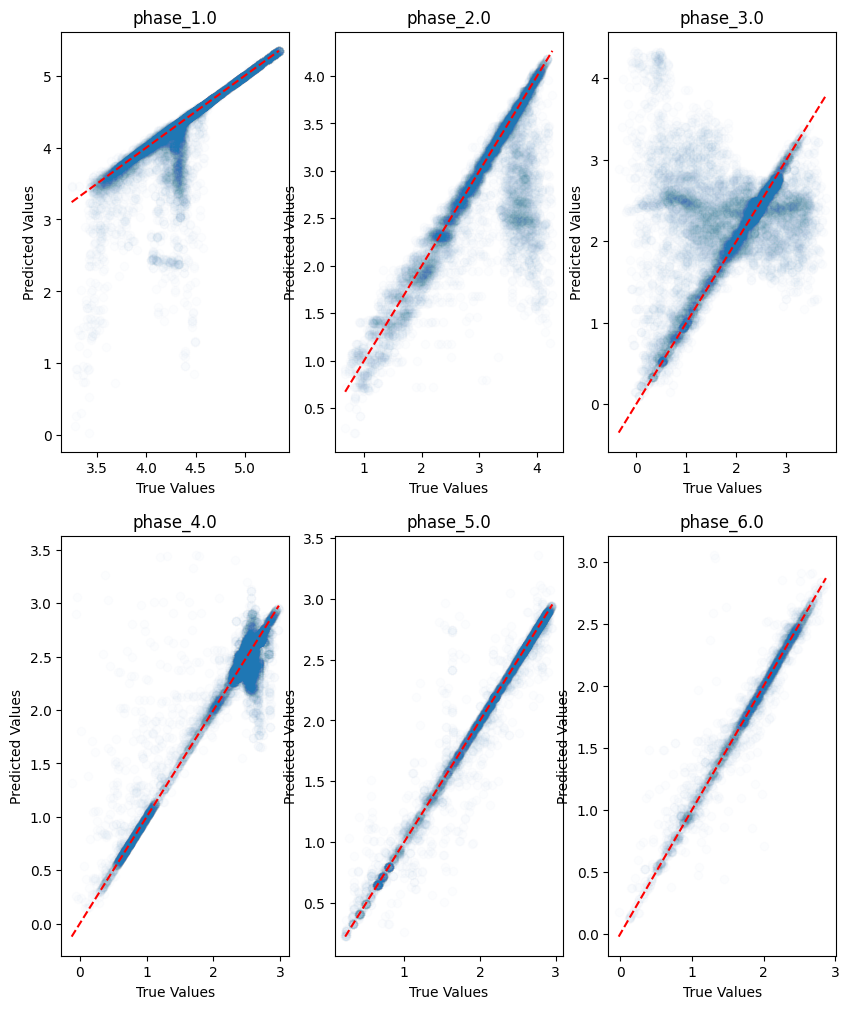

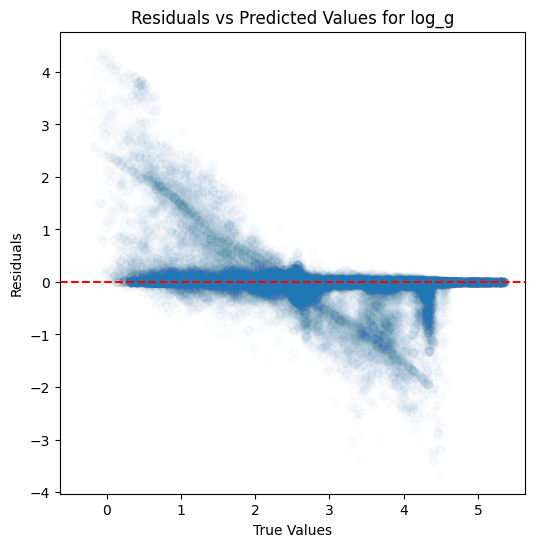

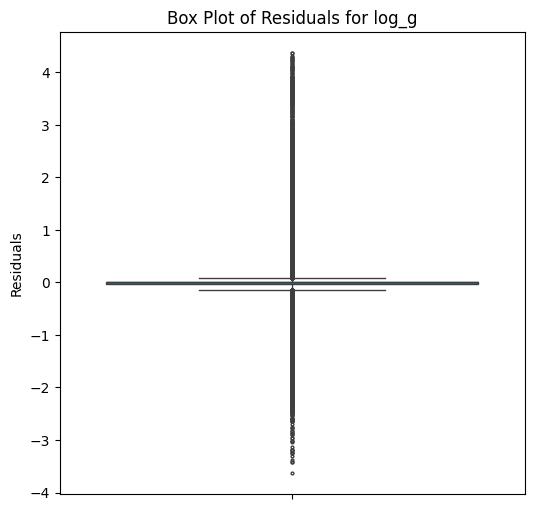

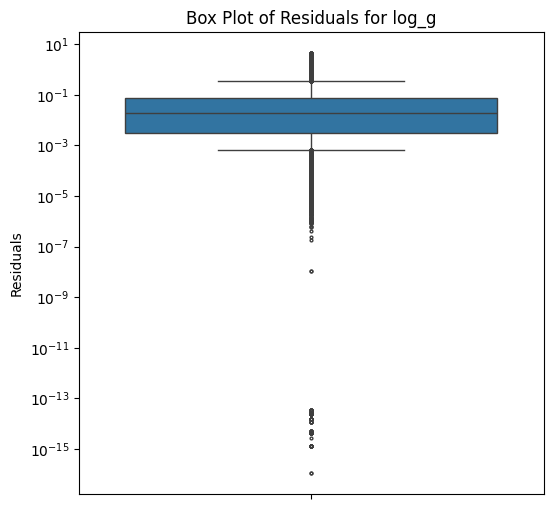

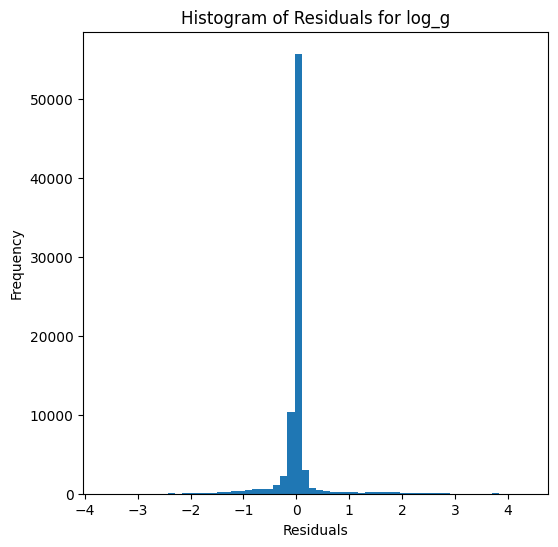

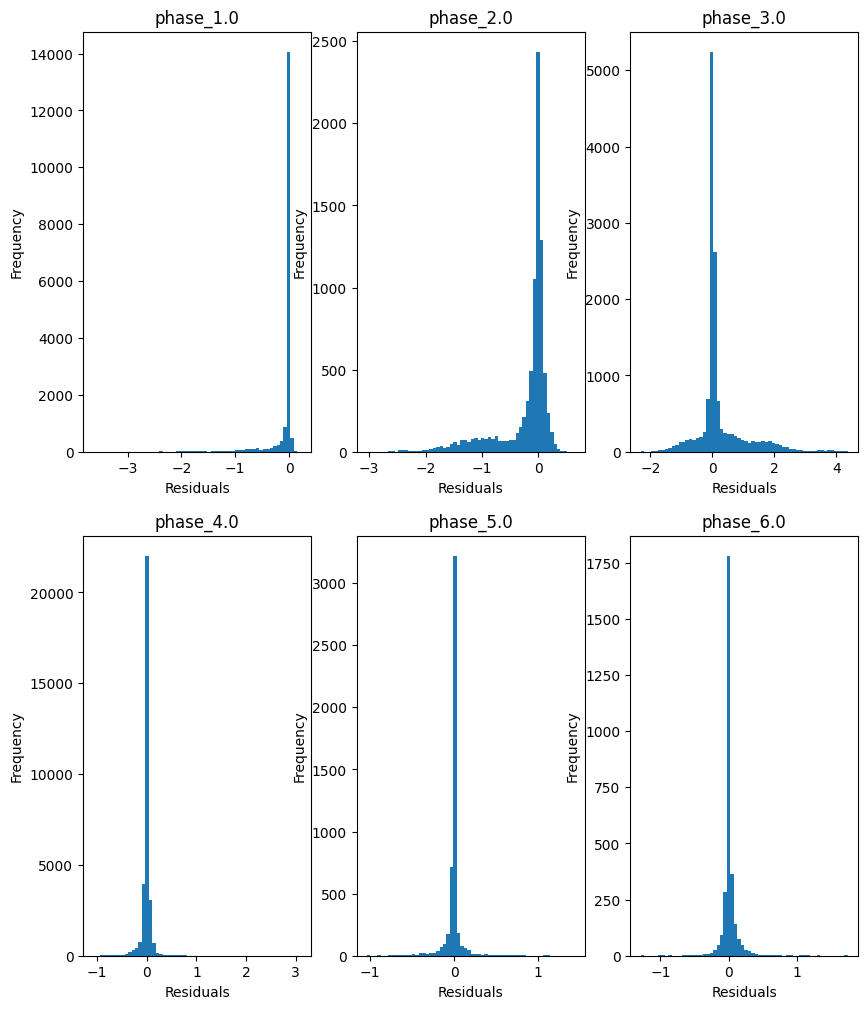

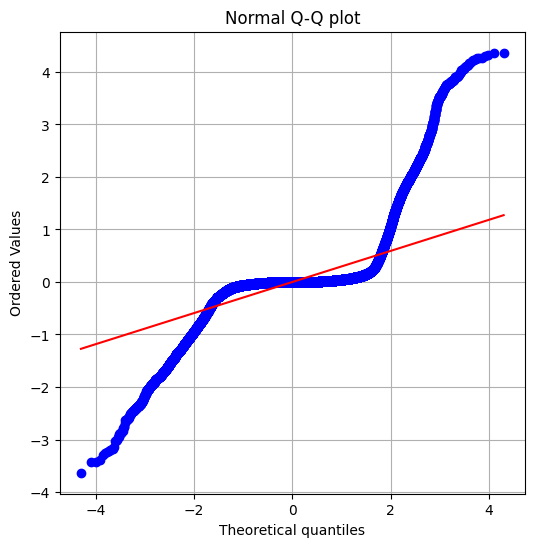

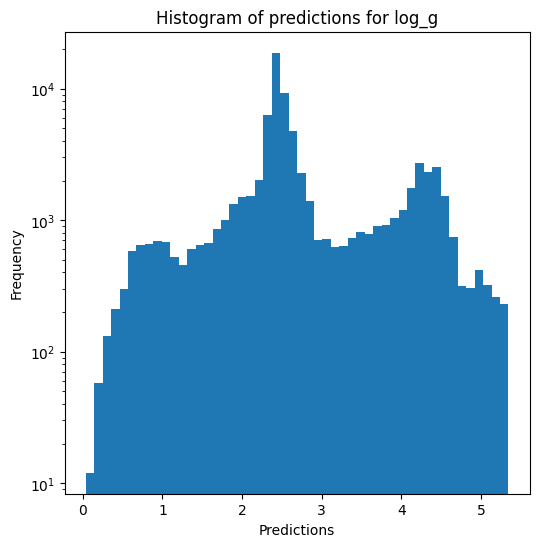

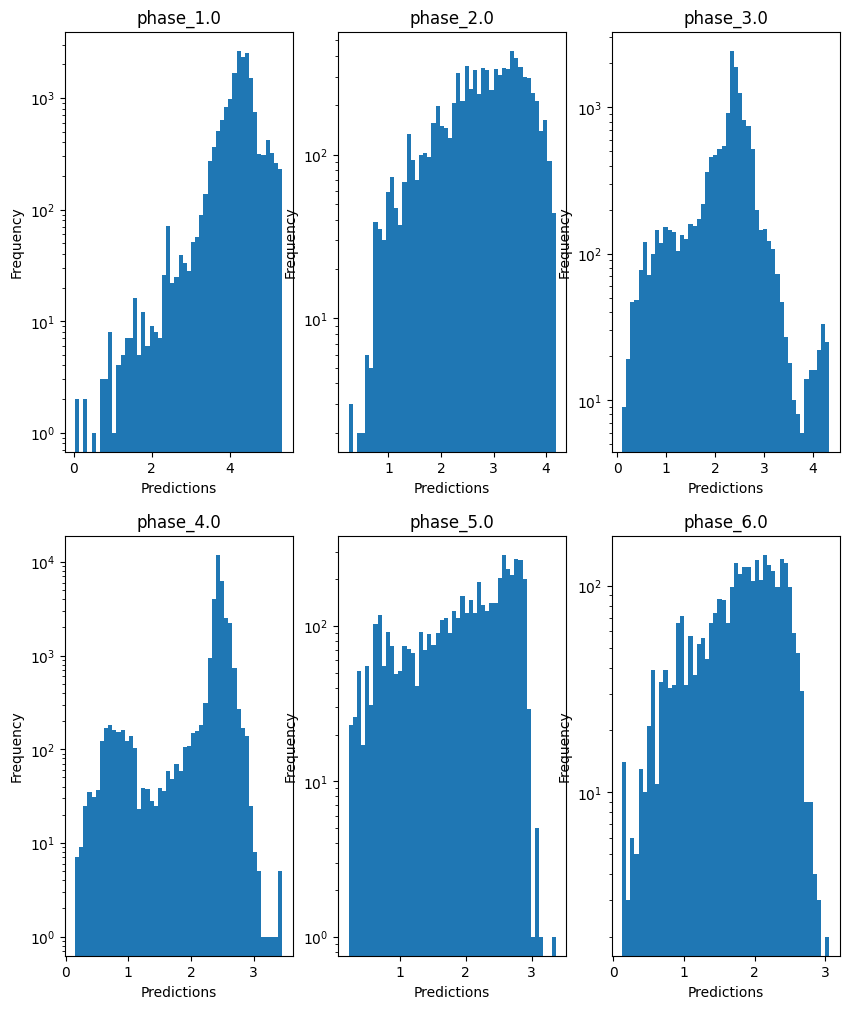

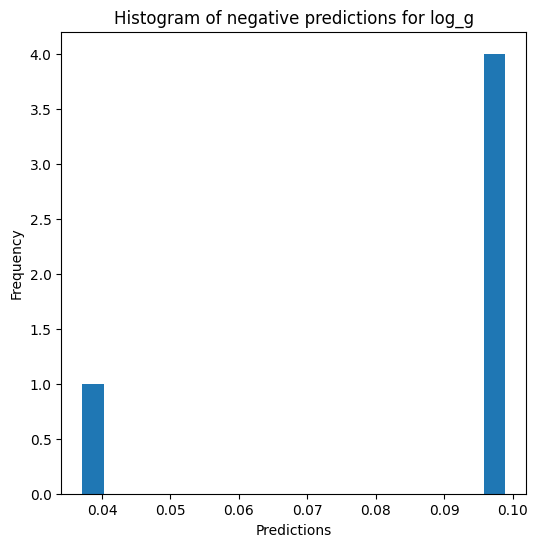

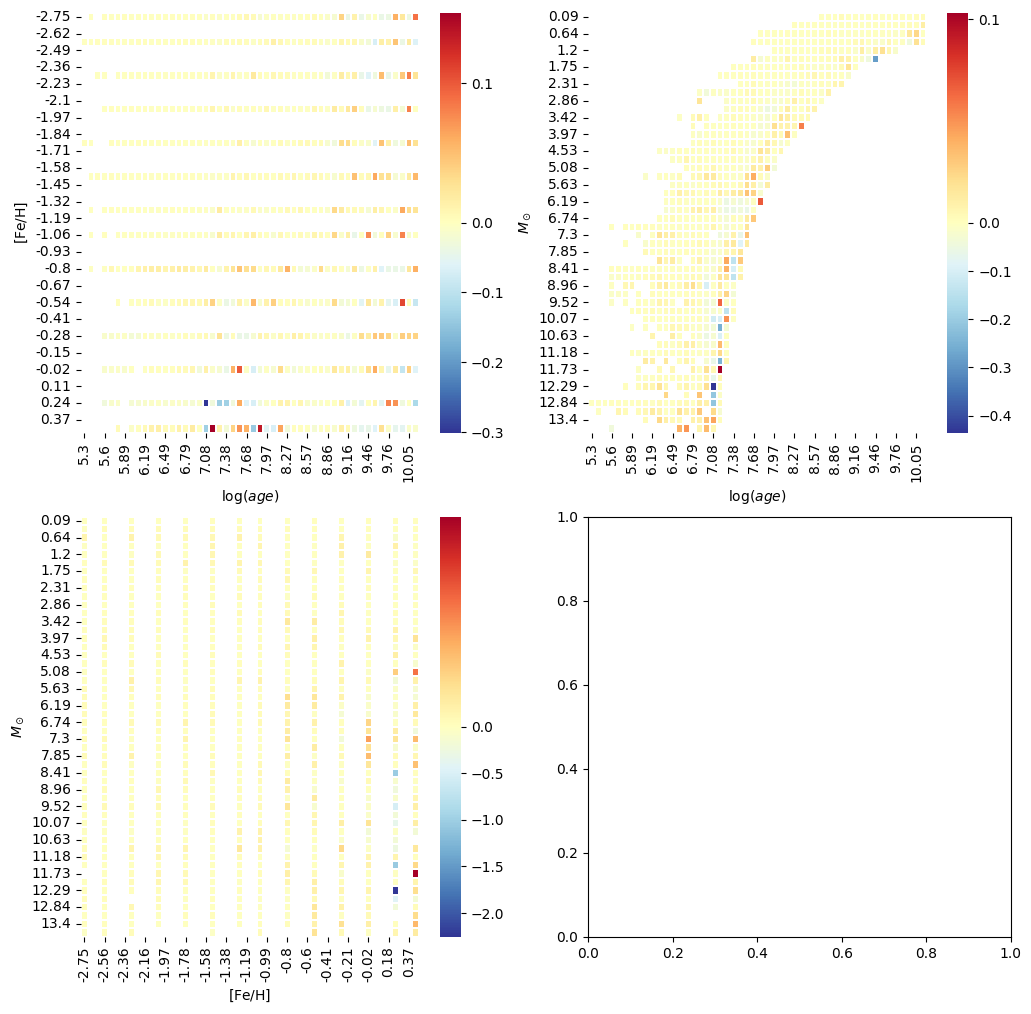

5.551115123125783e-16

radius results for the phase category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.8458361911029697
  RMSE :  0.14997652719459206
  MAE :  0.04357275573183348
  MedAE :  0.0028475227072014136
  CORR :  0.9328906375187854
  MAX_ER :  1.8160613434898558
  Percentiles : 
    75th percentile :  0.012361336049831962
    90th percentile :  0.0821500930271341
    95th percentile :  0.2818013637338873
    99th percentile :  0.8274698158649081

radius results for the phase category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.8039762269281393
  RMSE :  0.26370474638846697
  MAE :  0.13607670296543983
  MedAE :  0.035974147969566106
  CORR :  0.8966794011738428
  MAX_ER :  1.517089841293928
  Percentiles : 
    75th percentile :  0.11868314896089172
    90th percentile :  0.4974625594423883
    95th percentile :  0.6728805366090687
    99th percentile :  0.9660590516906344

radius results 

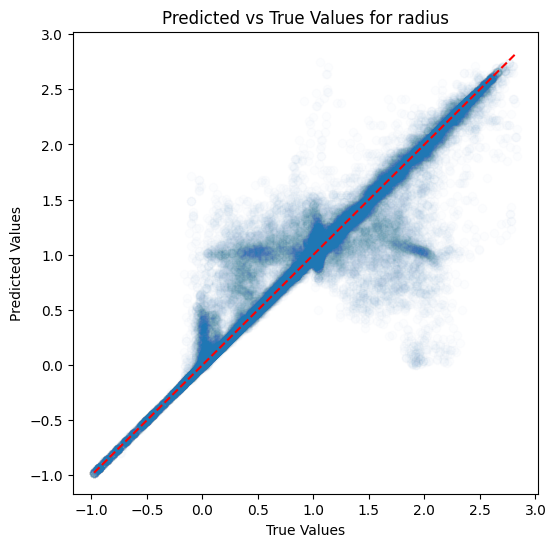

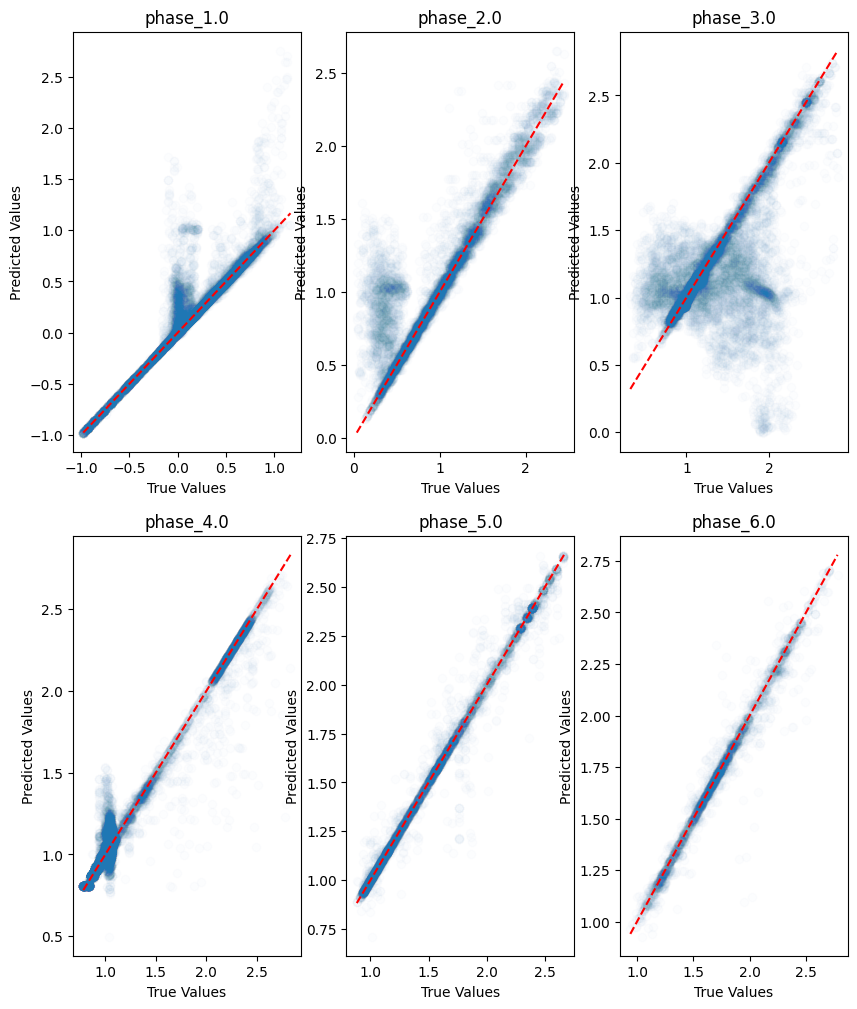

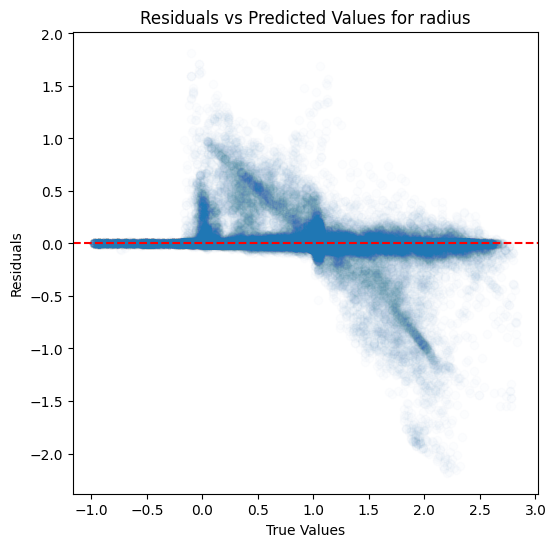

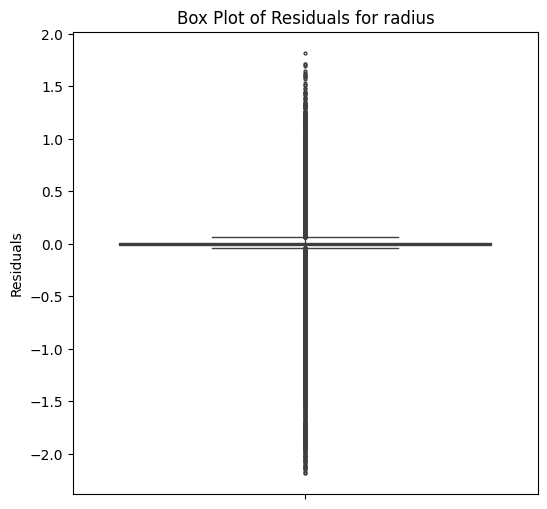

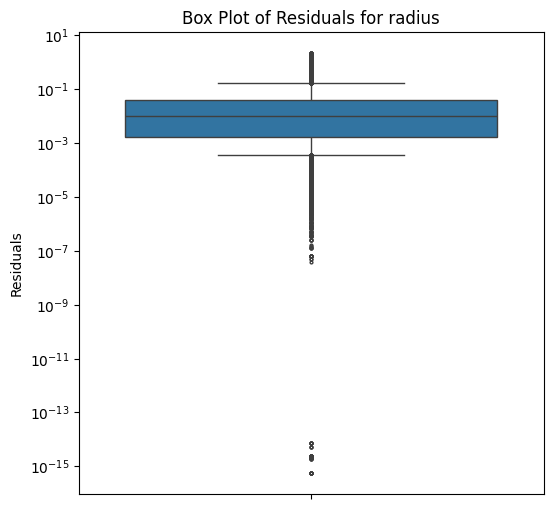

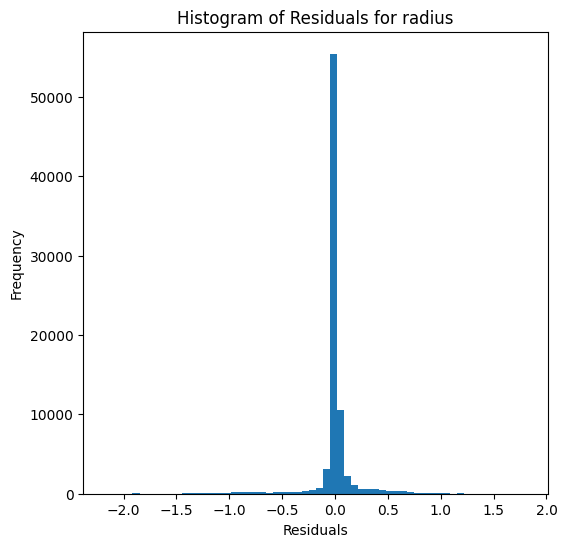

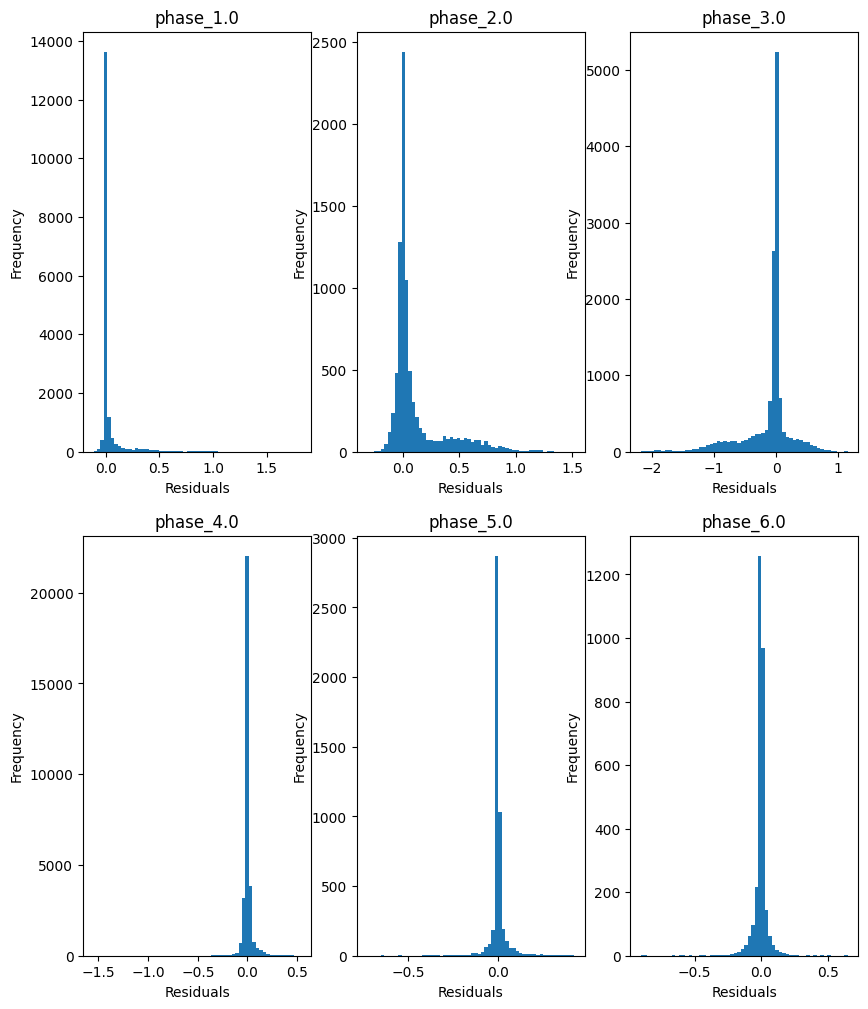

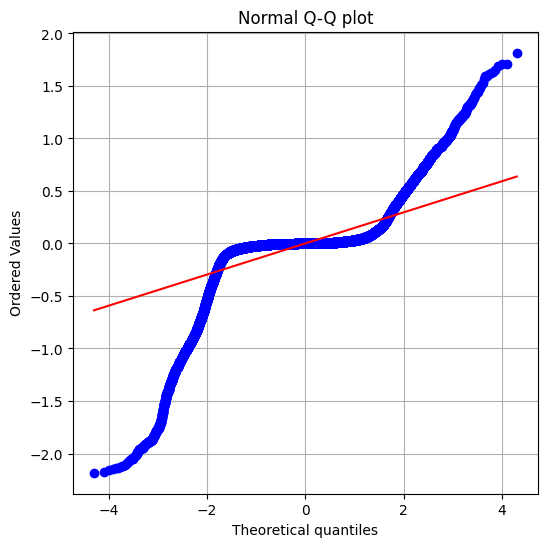

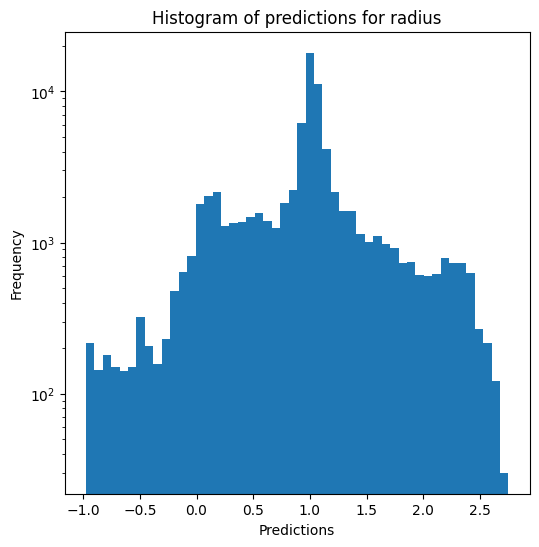

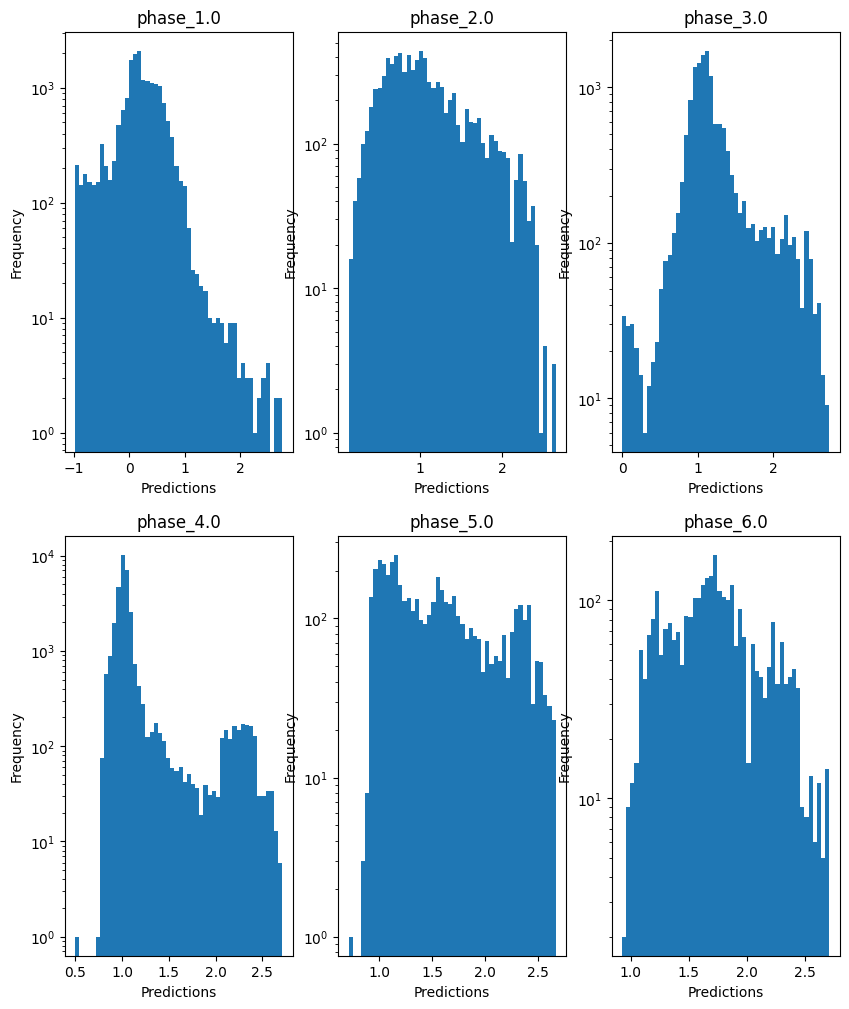

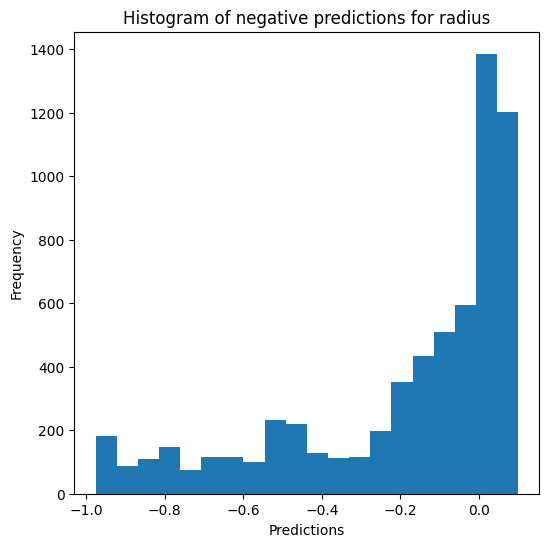

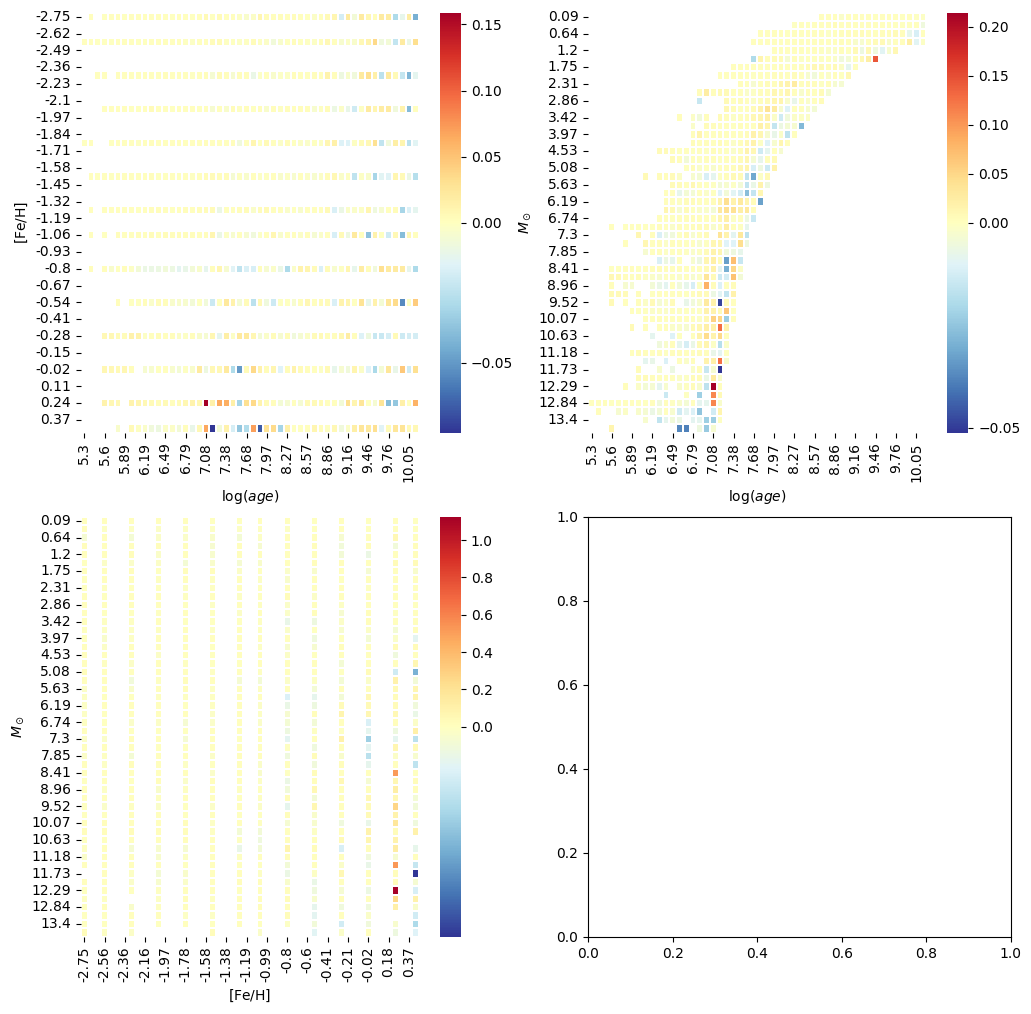

Saving predictions and results...


In [11]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 3, 'min_samples_split': 10, 'max_features': None, 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train_quantile, X_ivs_quantile, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=override, use_preds=use_preds, save=save, show=show, 
                               inputs=X_ivs, inputs_col_names=input_col_names, output_col_names=output_col_names, **best_params_RF)

## KNN

In [12]:
tag = "scale_power"

../../../../../../results/model_B/final_models/

scale_power train data :
Training the model...
Evaluating predictions...
0.0
no negative values

T_eff results for the phase category with a value of 1.0
  value range :  3.3622 - 4.5177
  RVE :  0.9750459994861356
  RMSE :  0.04289132785316836
  MAE :  0.012040957725615312
  MedAE :  0.0024300000000003763
  CORR :  0.9875238921270711
  MAX_ER :  0.7854899999999998
  Percentiles : 
    75th percentile :  0.008510000000000795
    90th percentile :  0.024119999999999874
    95th percentile :  0.040223999999999815
    99th percentile :  0.16453770000000567

T_eff results for the phase category with a value of 2.0
  value range :  3.602 - 4.4428
  RVE :  0.9111531940454642
  RMSE :  0.061104242948301975
  MAE :  0.04289799274344569
  MedAE :  0.03120999999999996
  CORR :  0.9555937052664674
  MAX_ER :  0.5678899999999998
  Percentiles : 
    75th percentile :  0.05915500000000007
    90th percentile :  0.09584400000000053
    95th percentile

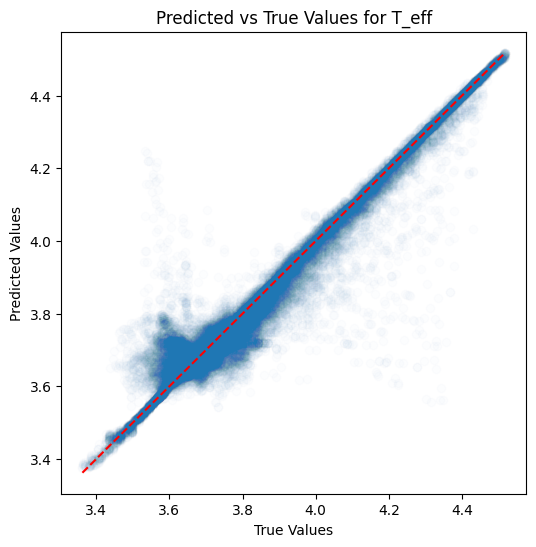

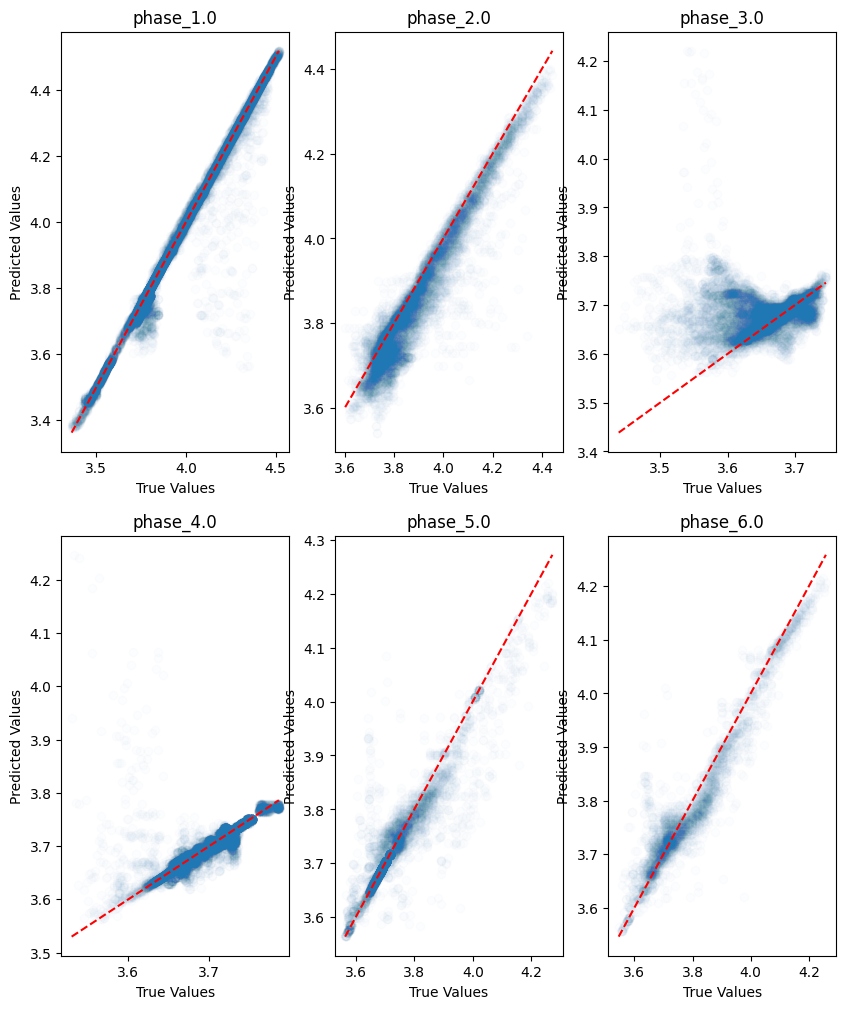

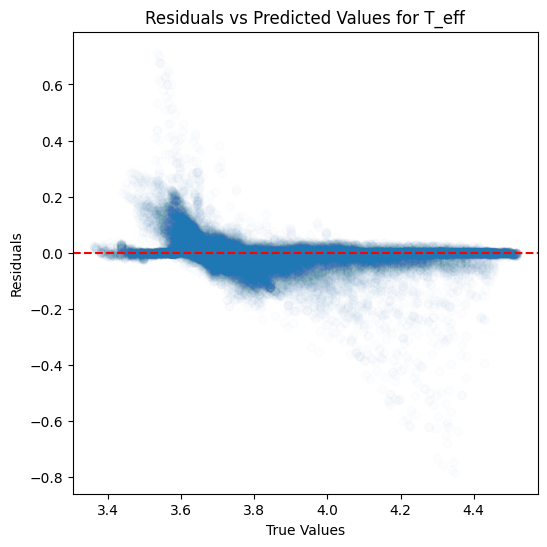

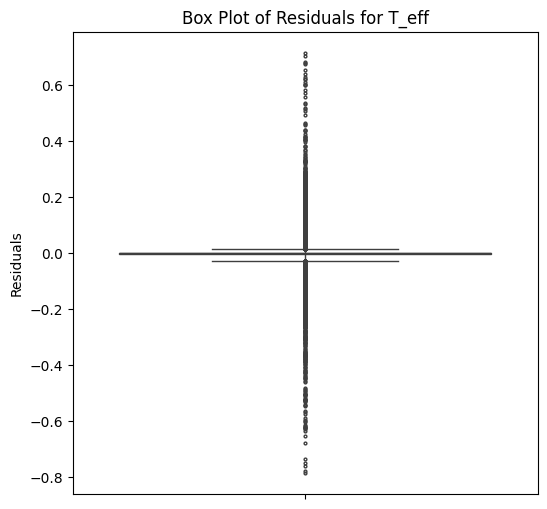

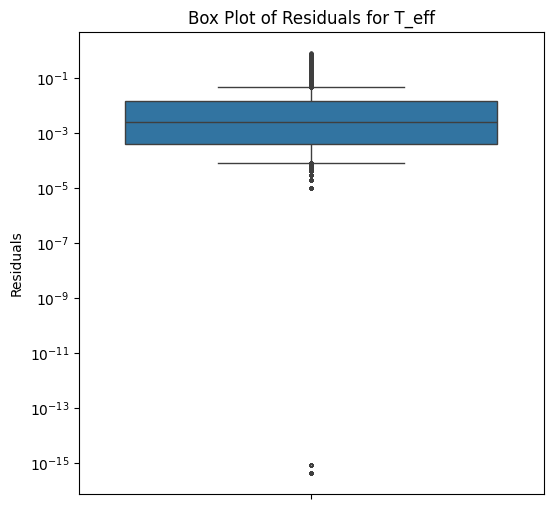

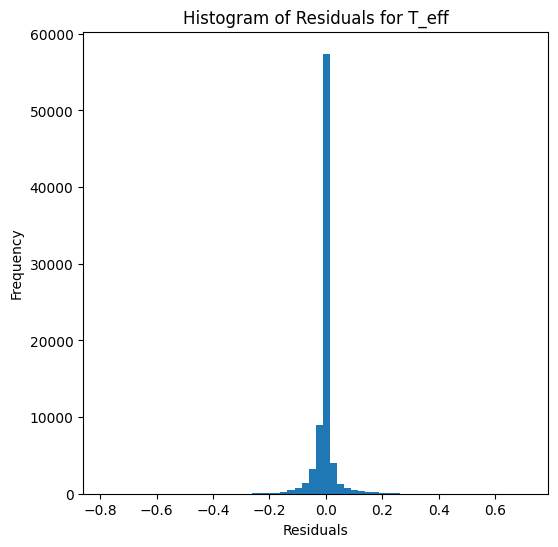

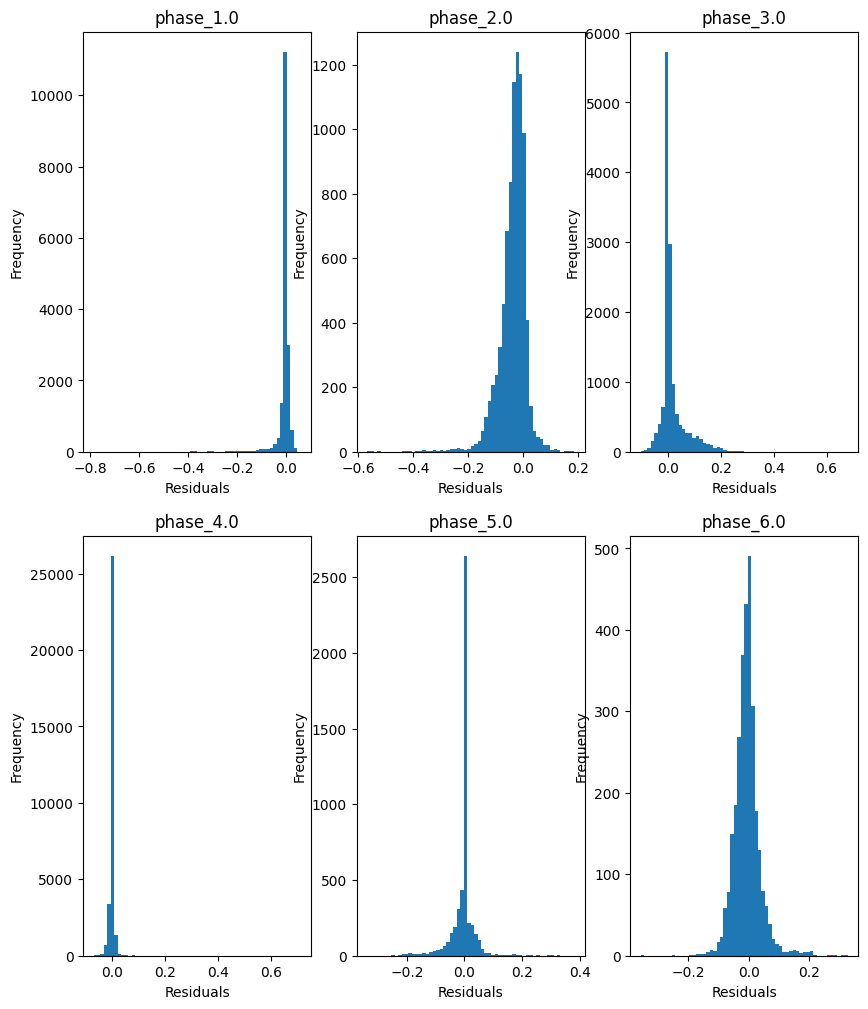

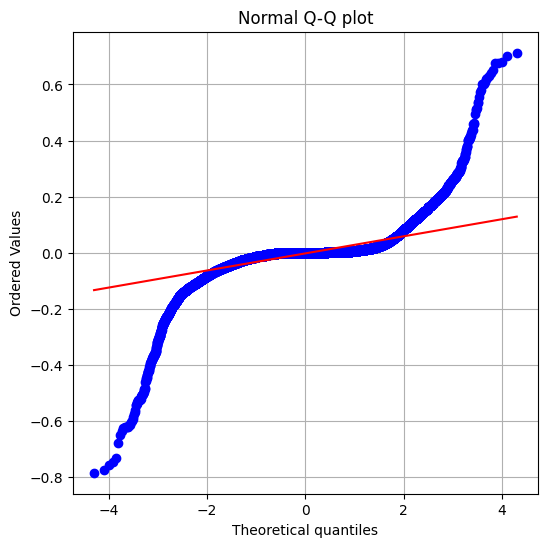

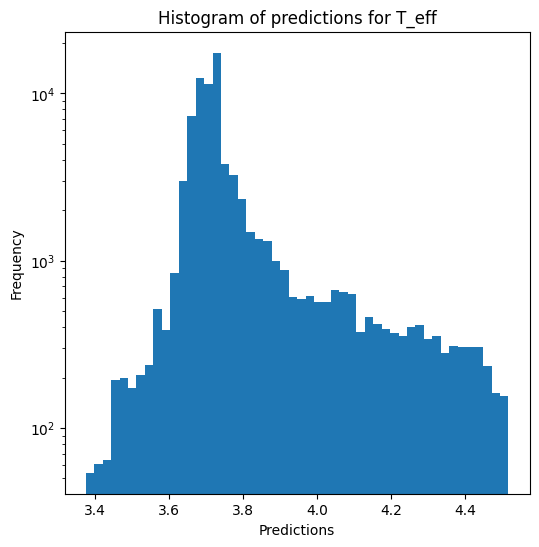

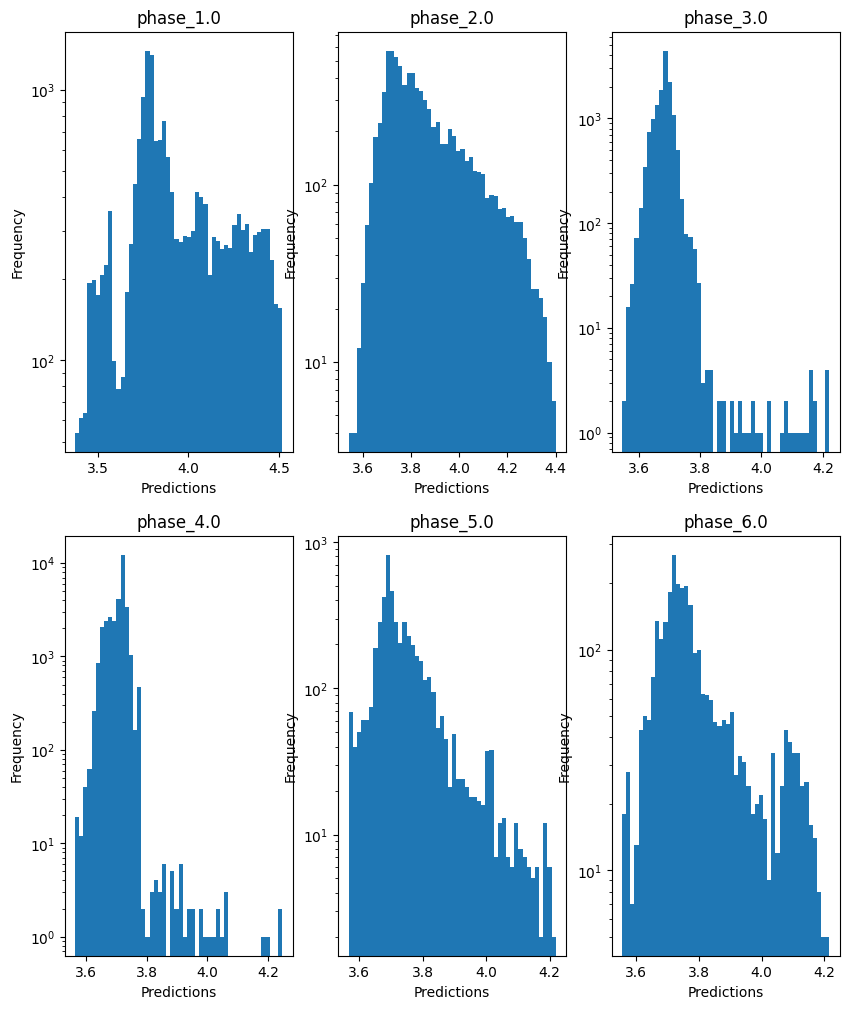

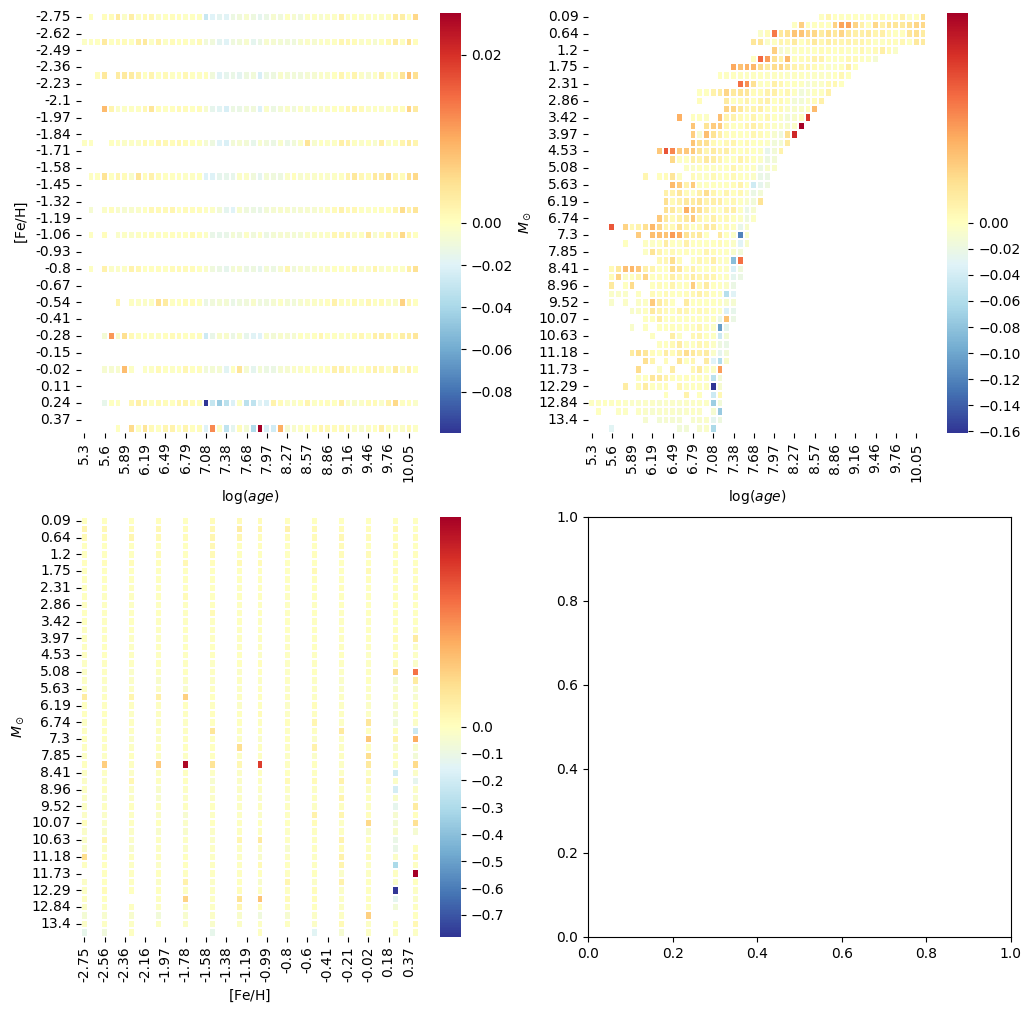

0.0

log_g results for the phase category with a value of 1.0
  value range :  3.241 - 5.345
  RVE :  0.04990062231013781
  RMSE :  0.3476110709665336
  MAE :  0.10460587397447586
  MedAE :  0.006700000000000372
  CORR :  0.7696123004008696
  MAX_ER :  3.4656999999999996
  Percentiles : 
    75th percentile :  0.02880000000000038
    90th percentile :  0.37380000000000013
    95th percentile :  0.44438000000000066
    99th percentile :  1.9206800000000033

log_g results for the phase category with a value of 2.0
  value range :  0.672 - 4.266
  RVE :  0.6484552651932723
  RMSE :  0.5647100951877659
  MAE :  0.33060972612359557
  MedAE :  0.13465000000000016
  CORR :  0.8178076984433407
  MAX_ER :  3.2024999999999997
  Percentiles : 
    75th percentile :  0.3561249999999997
    90th percentile :  1.02955
    95th percentile :  1.3183199999999993
    99th percentile :  1.9984129999999998

log_g results for the phase category with a value of 3.0
  value range :  -0.347 - 3.787
  RVE :  -

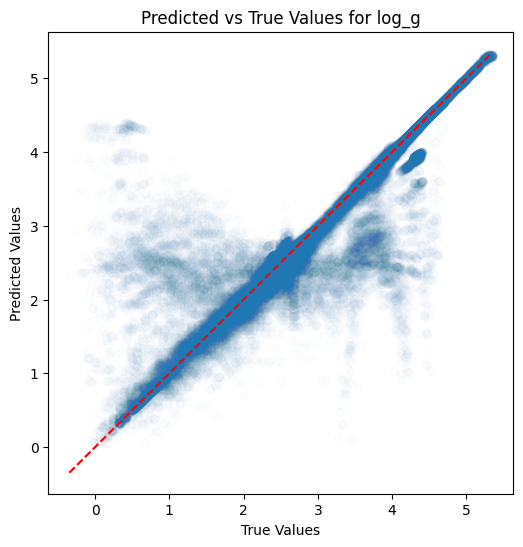

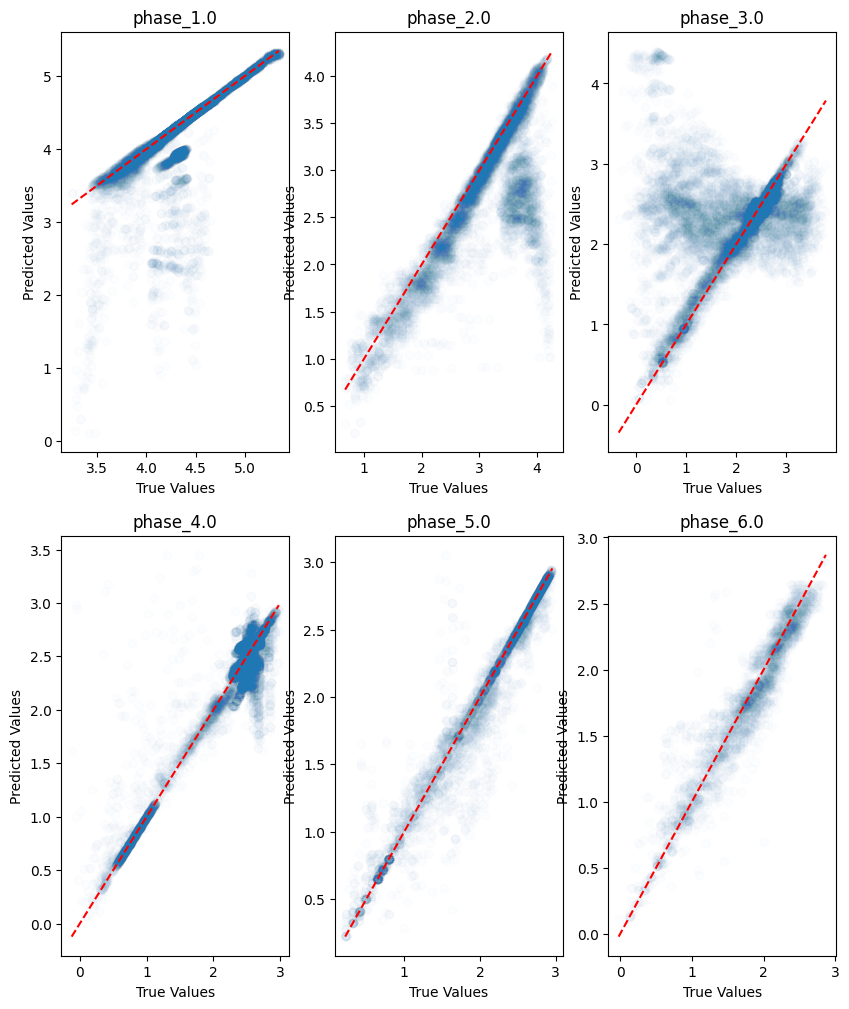

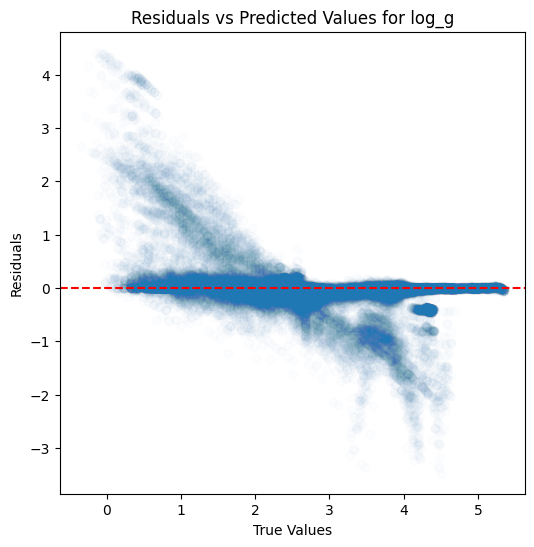

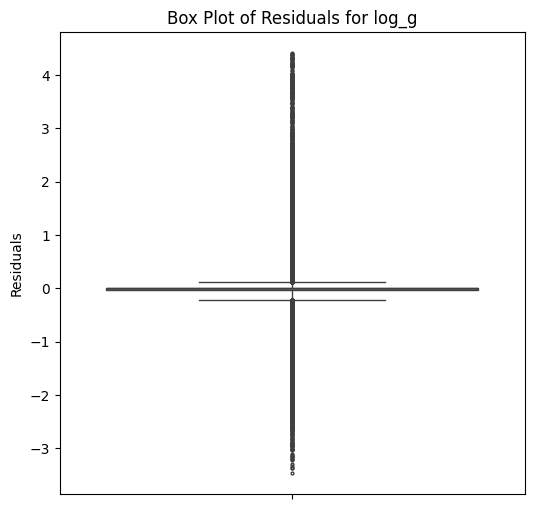

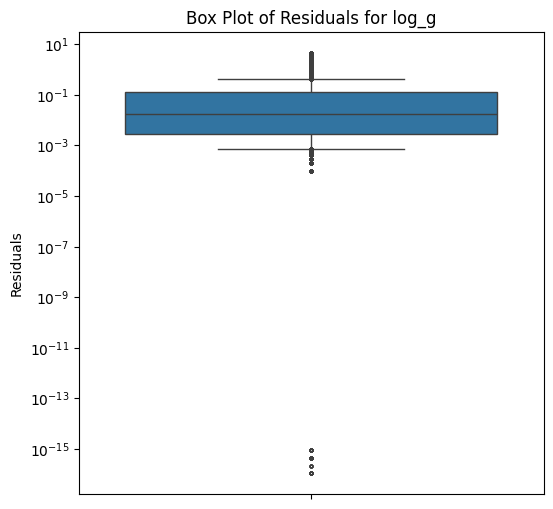

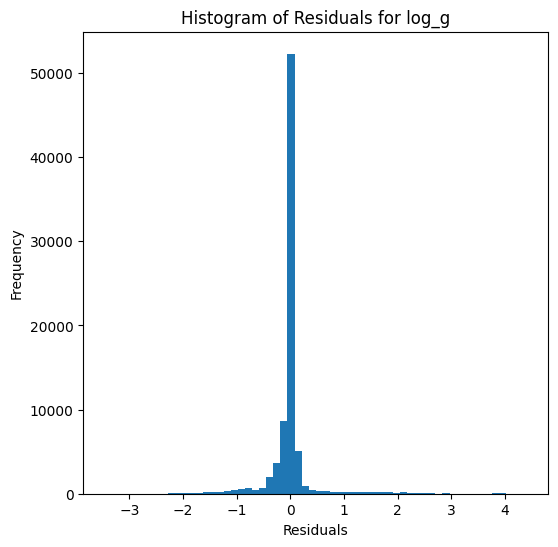

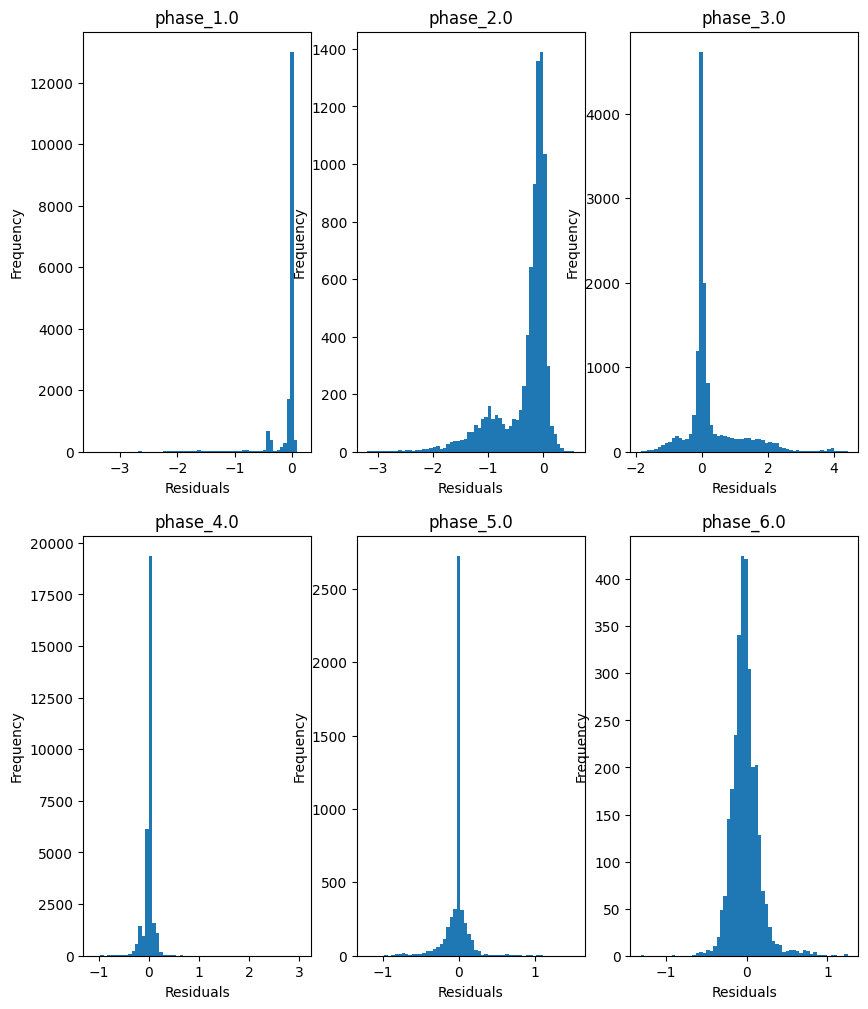

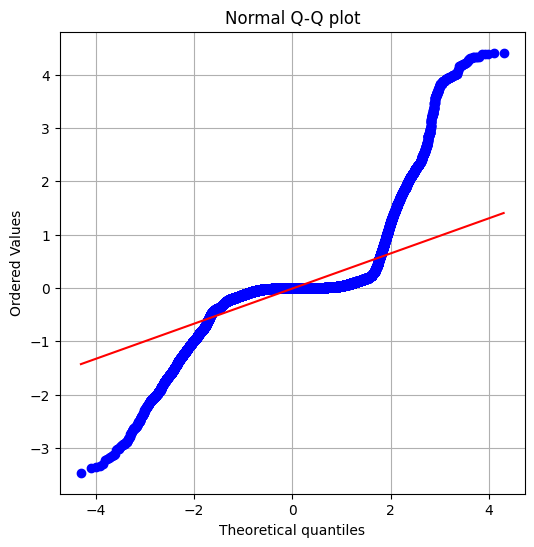

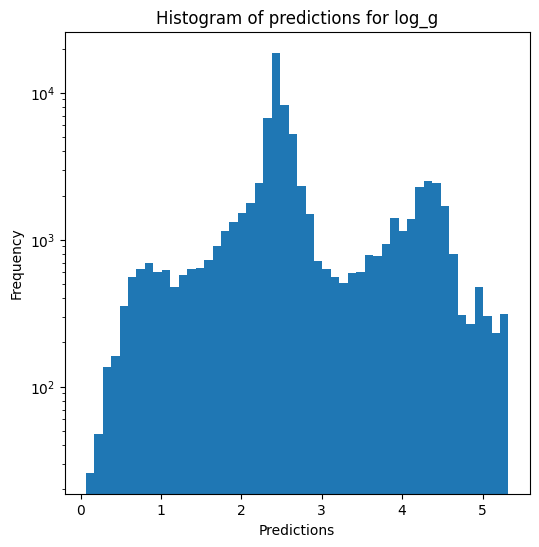

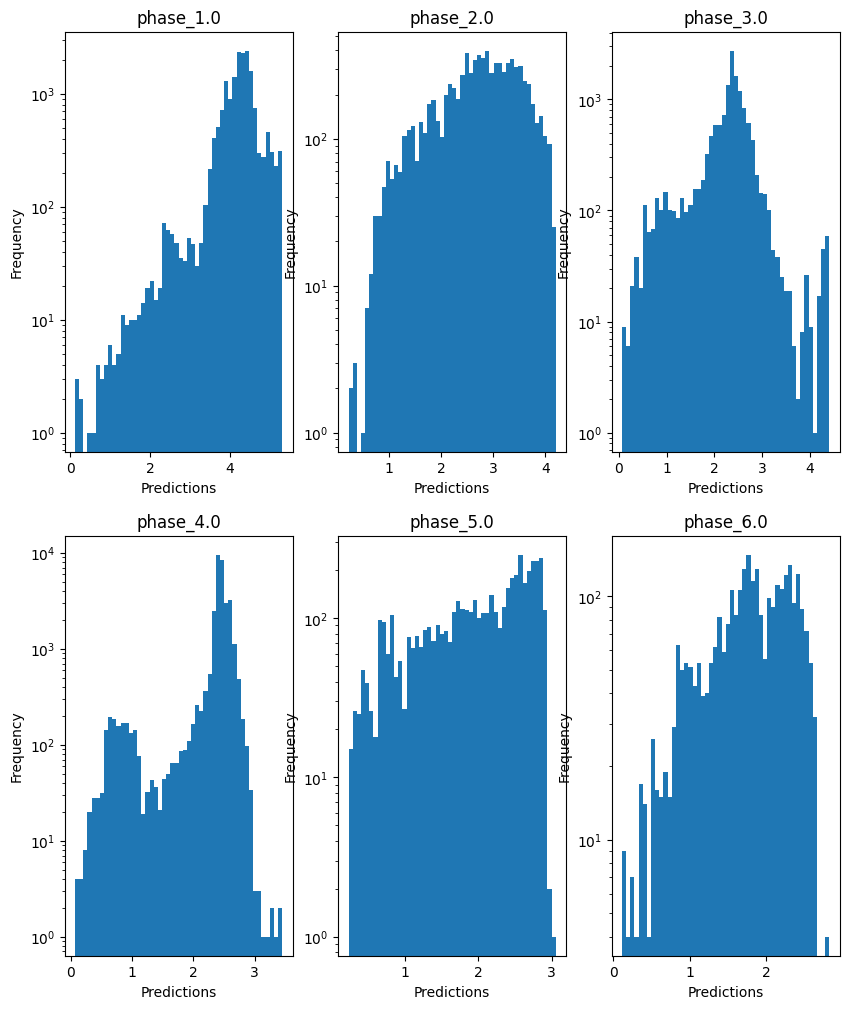

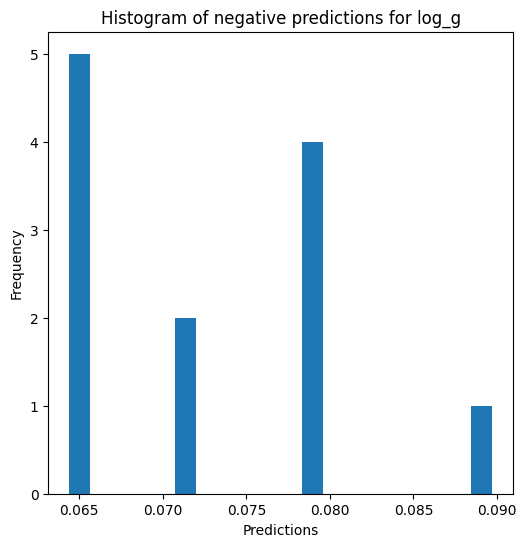

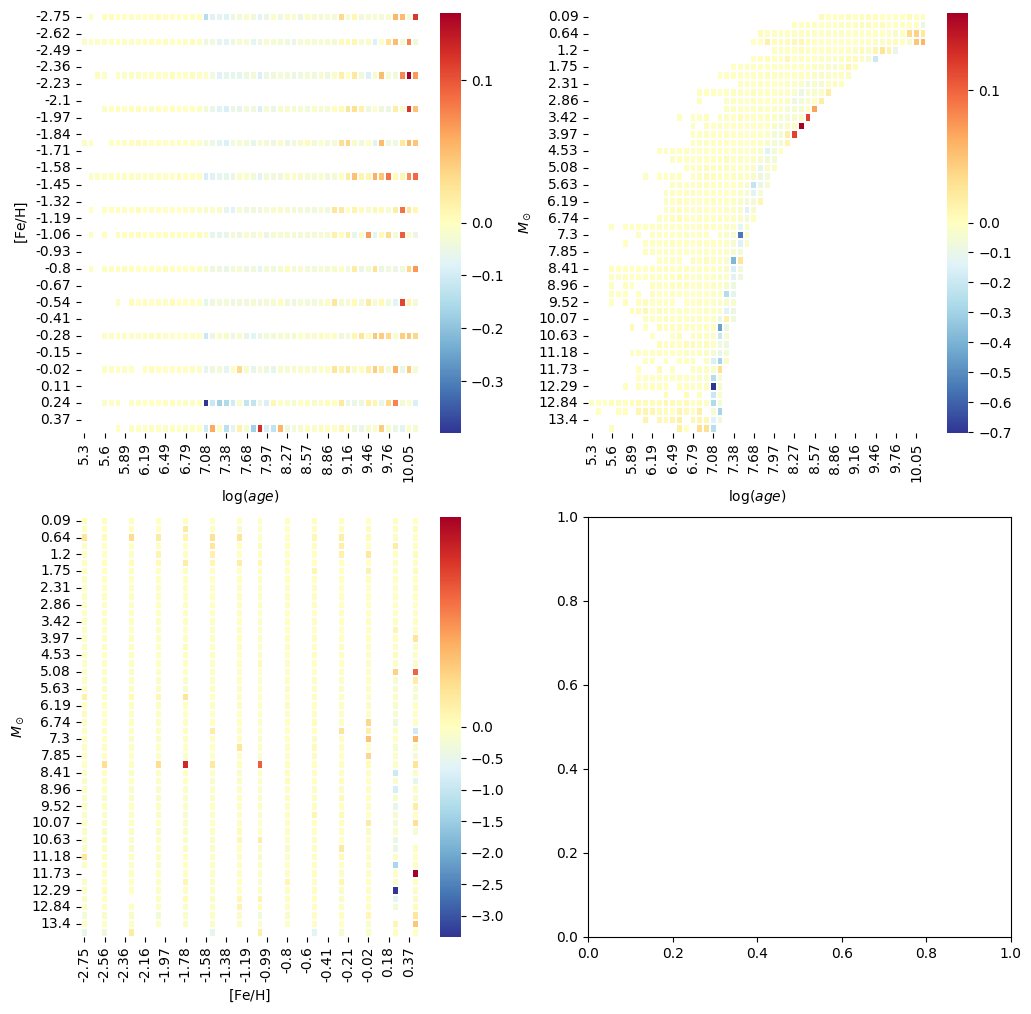

0.0

radius results for the phase category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.7942482758349516
  RMSE :  0.17452412033938236
  MAE :  0.05411627306223335
  MedAE :  0.005685835755404572
  CORR :  0.9147917039173825
  MAX_ER :  1.7332127948462461
  Percentiles : 
    75th percentile :  0.018862527626662906
    90th percentile :  0.18698412593243927
    95th percentile :  0.2223370252445428
    99th percentile :  0.9612011017458798

radius results for the phase category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.8083849973353154
  RMSE :  0.28244383513703714
  MAE :  0.1654104393460247
  MedAE :  0.06740675770224425
  CORR :  0.8991682953509462
  MAX_ER :  1.6017493869408512
  Percentiles : 
    75th percentile :  0.17845443659863403
    90th percentile :  0.514447391475768
    95th percentile :  0.6593510480707294
    99th percentile :  0.9989356315892578

radius results for the phase catego

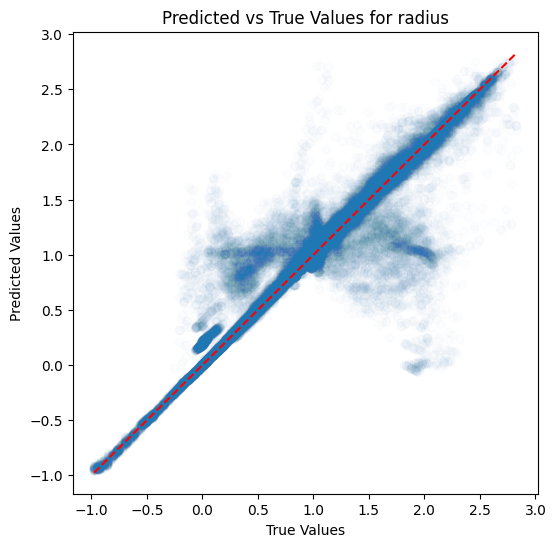

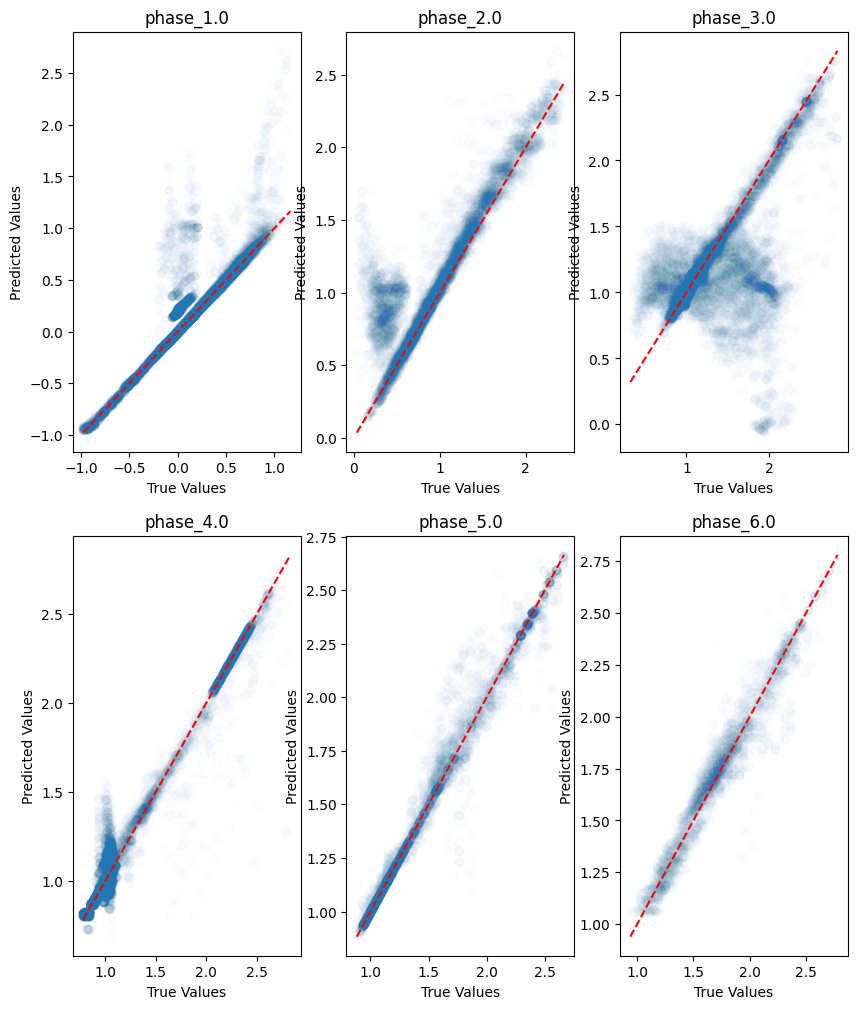

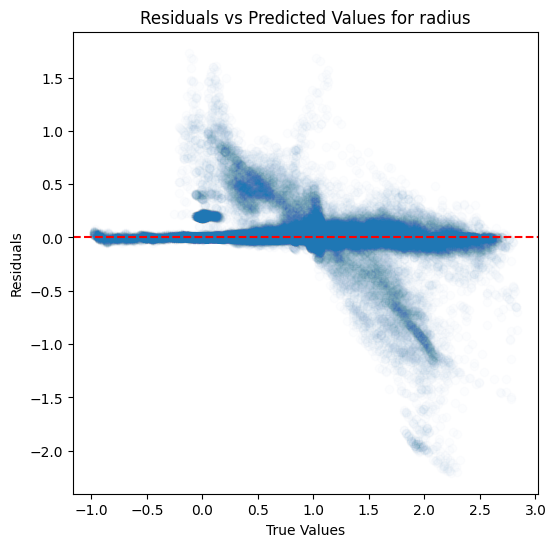

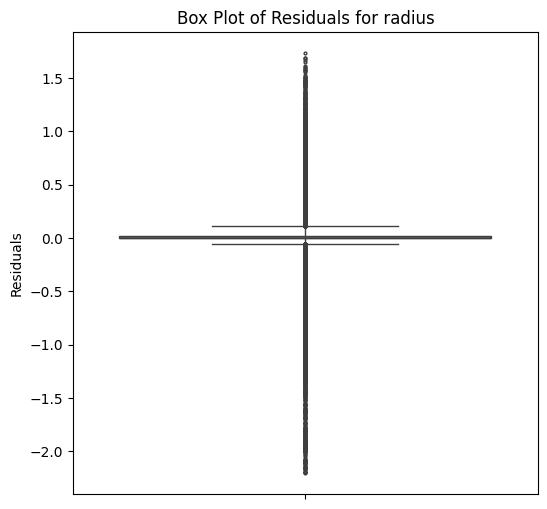

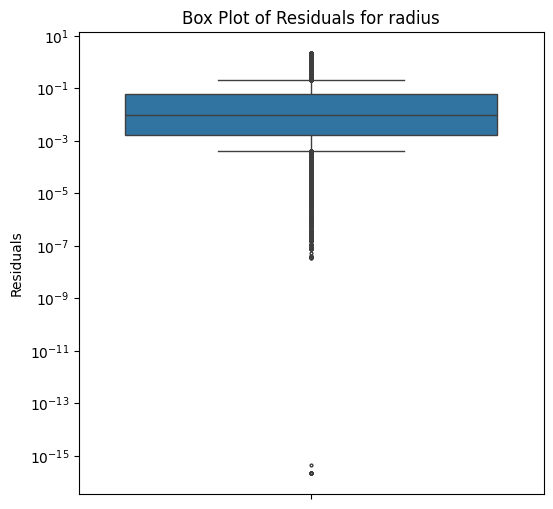

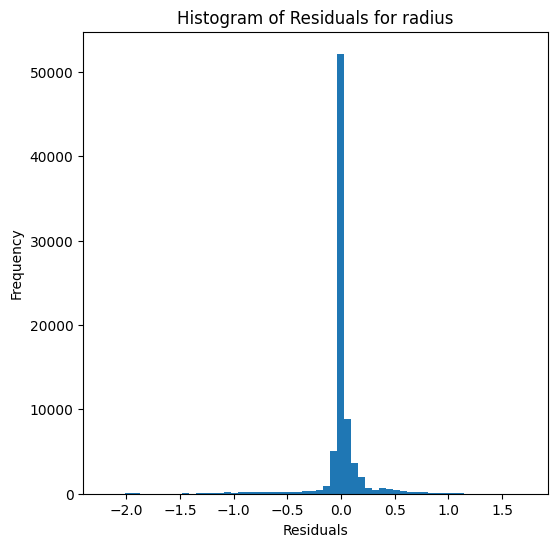

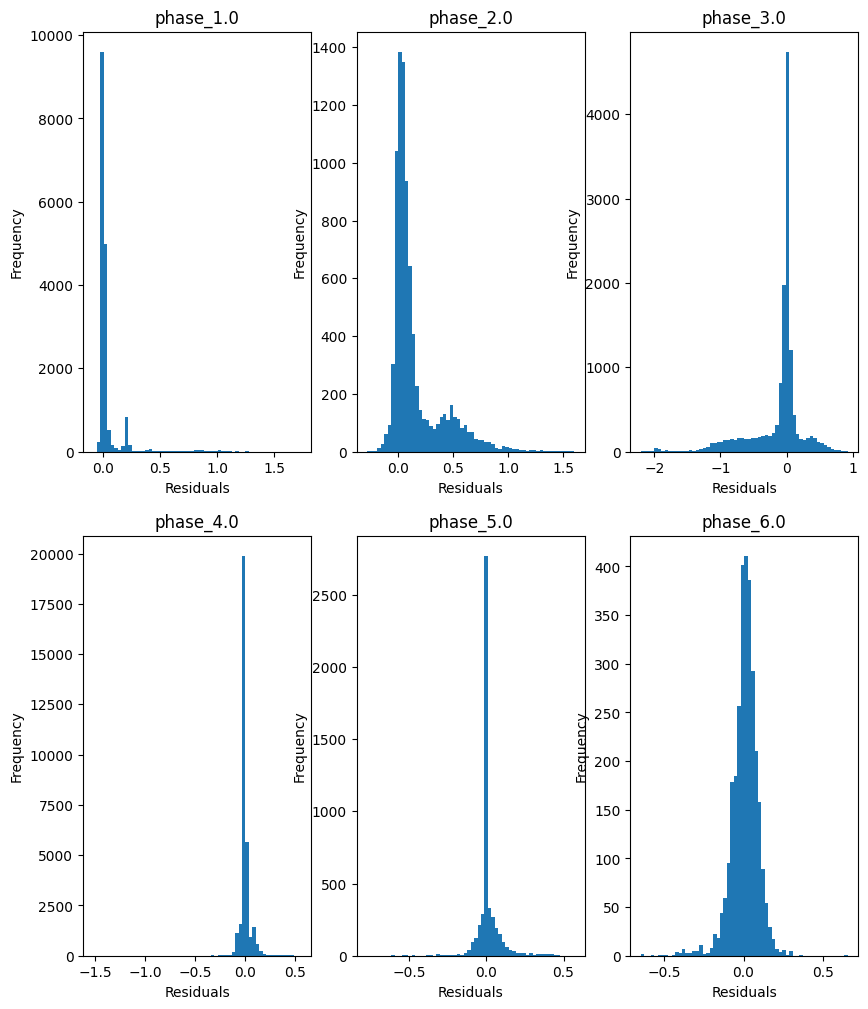

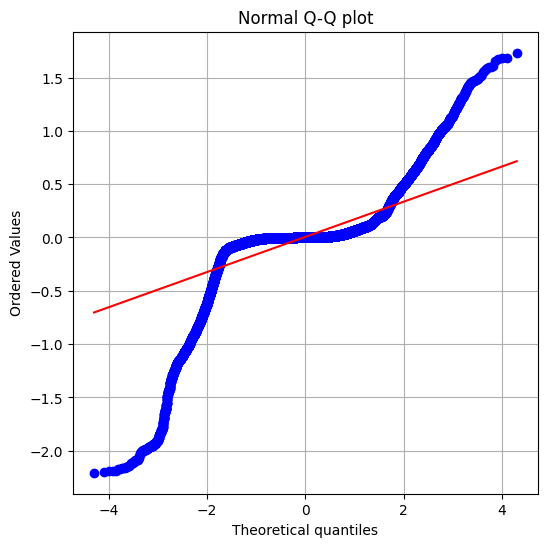

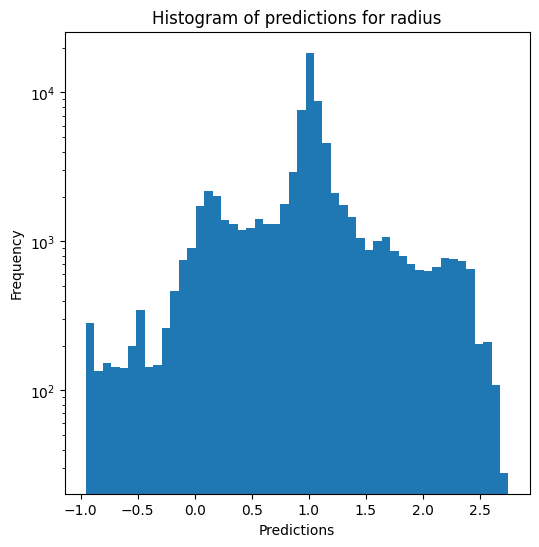

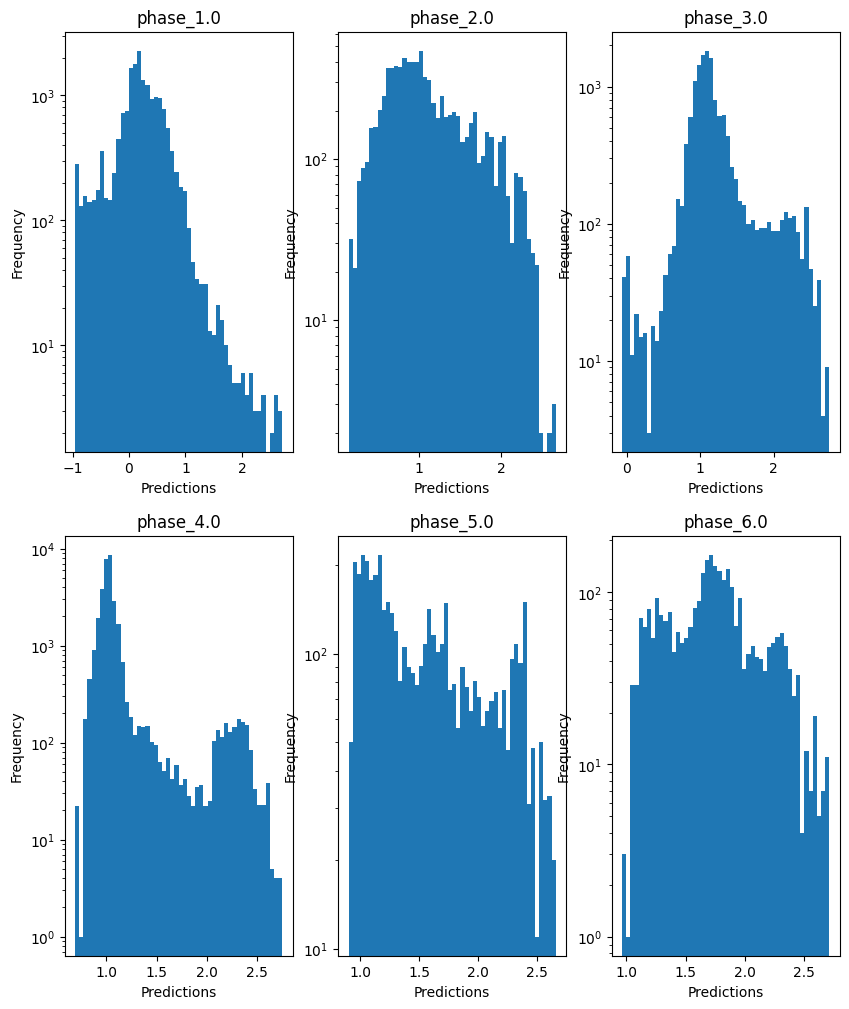

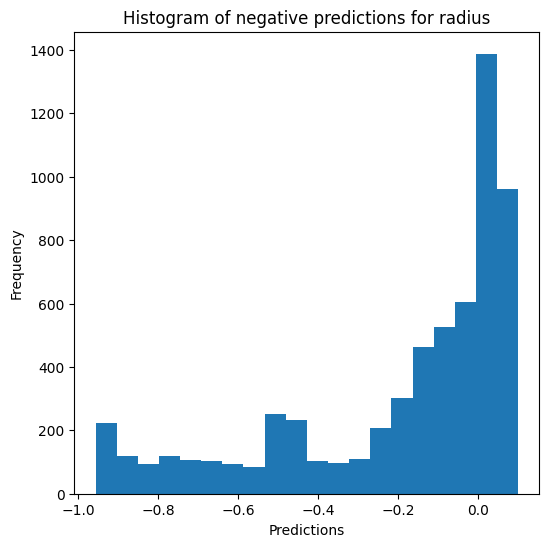

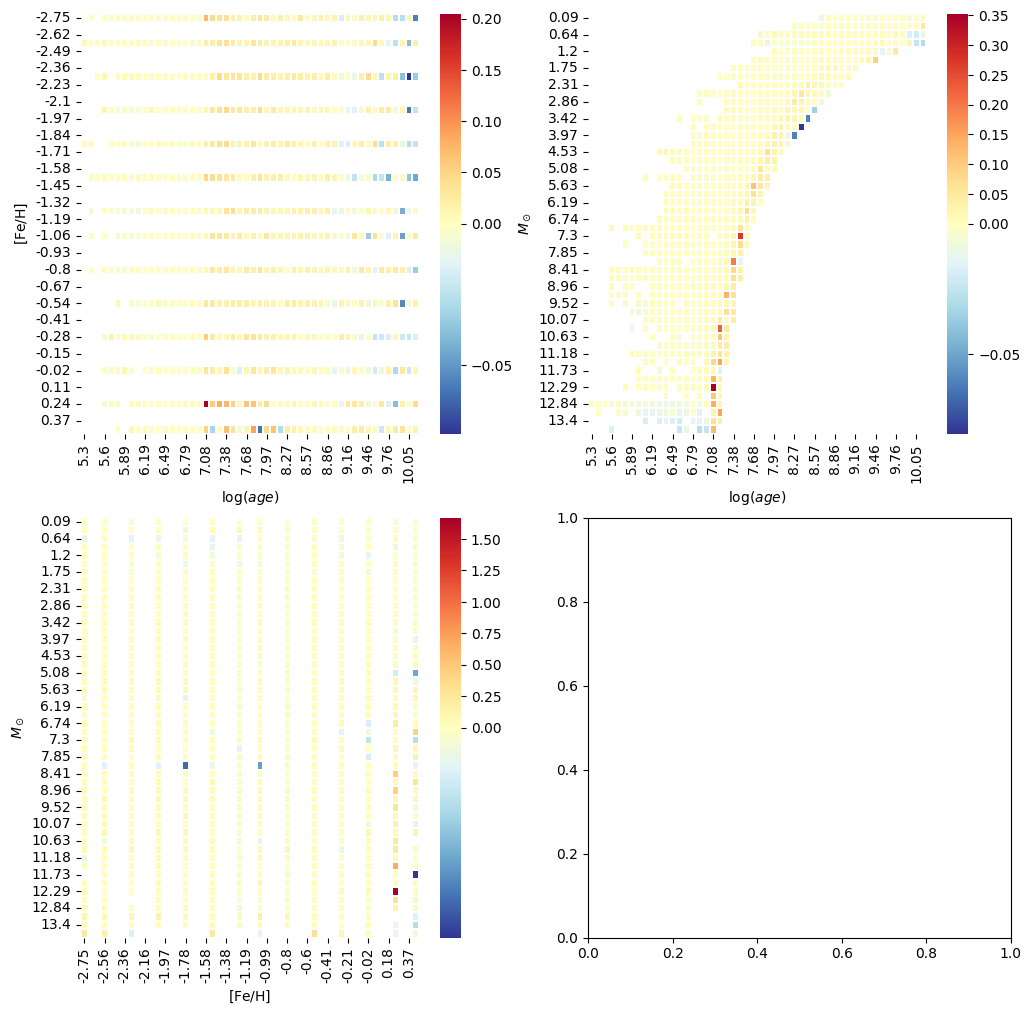

Saving predictions and results...


In [13]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'ball_tree', 'leaf_size': 75, 'n_neighbors': 10, 'weights': 'uniform'}

print(path_to_results)
evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(KNeighborsRegressor, X_train_power, X_ivs_power, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=override, use_preds=use_preds, save=save, show=show, 
                               inputs=X_ivs, inputs_col_names=input_col_names, output_col_names=output_col_names, **best_params_KNN)

## Decision tree

In [14]:
tag = "scale_power"

../../../../../../results/model_B/final_models/

scale_power train data :
Training the model...
Evaluating predictions...
0.0
no negative values

T_eff results for the phase category with a value of 1.0
  value range :  3.3622 - 4.5177
  RVE :  0.9763090647358637
  RMSE :  0.041601685149659166
  MAE :  0.009758027130940854
  MedAE :  0.000688888888888739
  CORR :  0.9882664075956833
  MAX_ER :  0.8056800000000006
  Percentiles : 
    75th percentile :  0.005539999999999878
    90th percentile :  0.019777000000000322
    95th percentile :  0.03912722222222228
    99th percentile :  0.13155558333333398

T_eff results for the phase category with a value of 2.0
  value range :  3.602 - 4.4428
  RVE :  0.9022079151961194
  RMSE :  0.054211232482235555
  MAE :  0.03395911768874778
  MedAE :  0.019156060606060565
  CORR :  0.9547769641659736
  MAX_ER :  0.5610421052631582
  Percentiles : 
    75th percentile :  0.046844642857143515
    90th percentile :  0.08326886363636325
    95th percentil

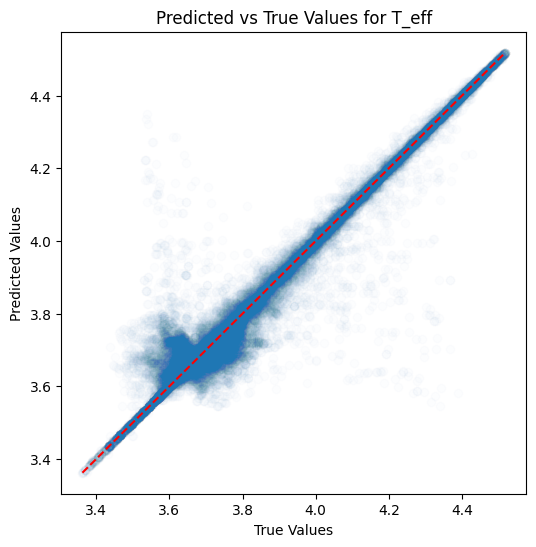

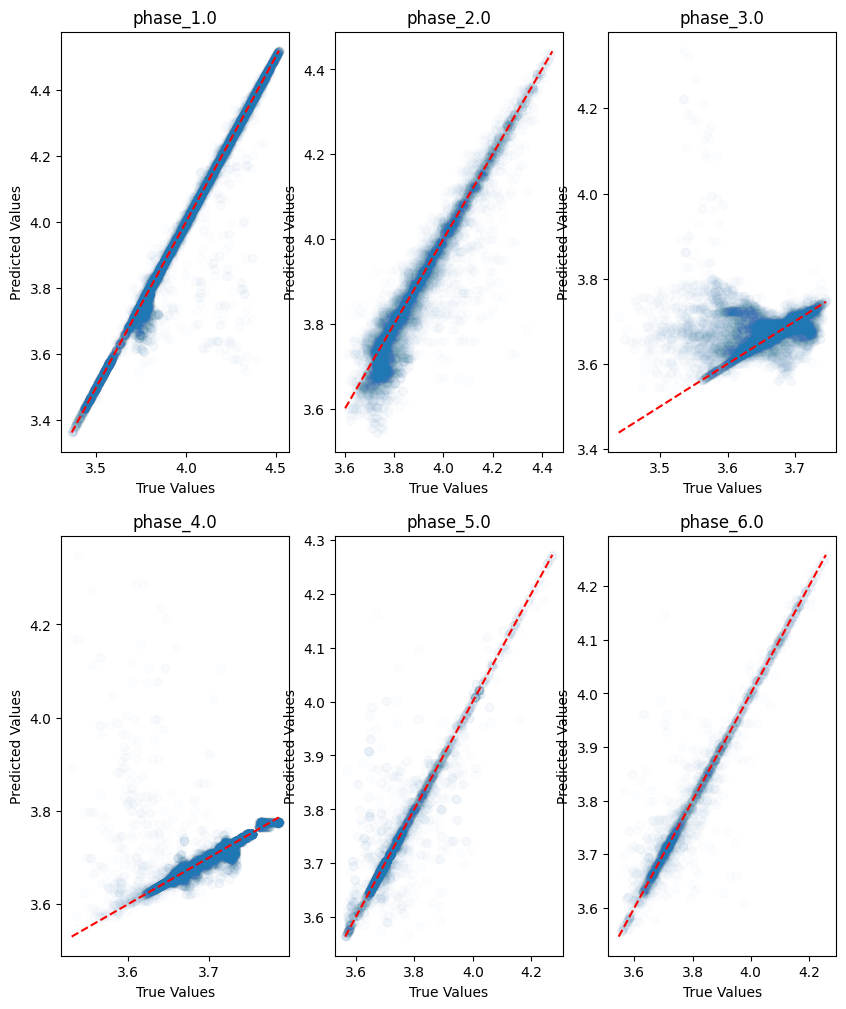

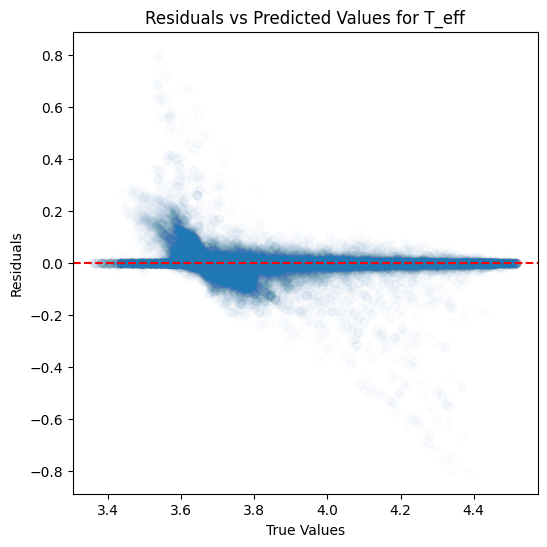

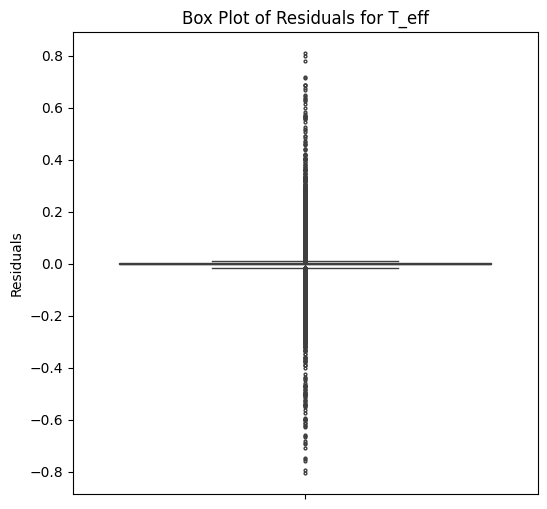

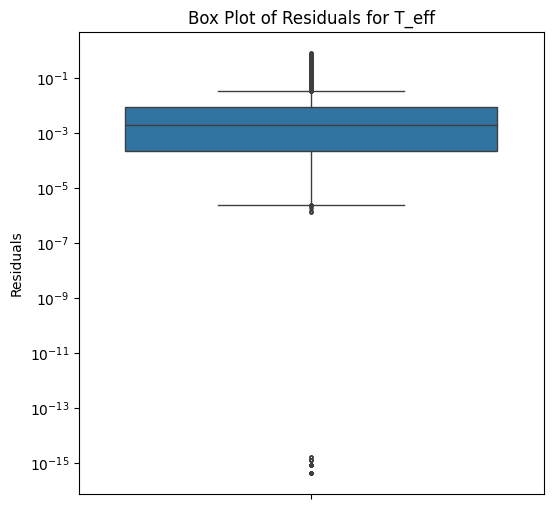

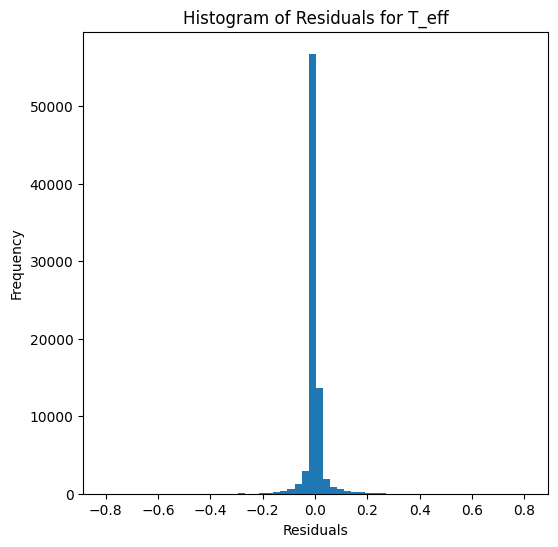

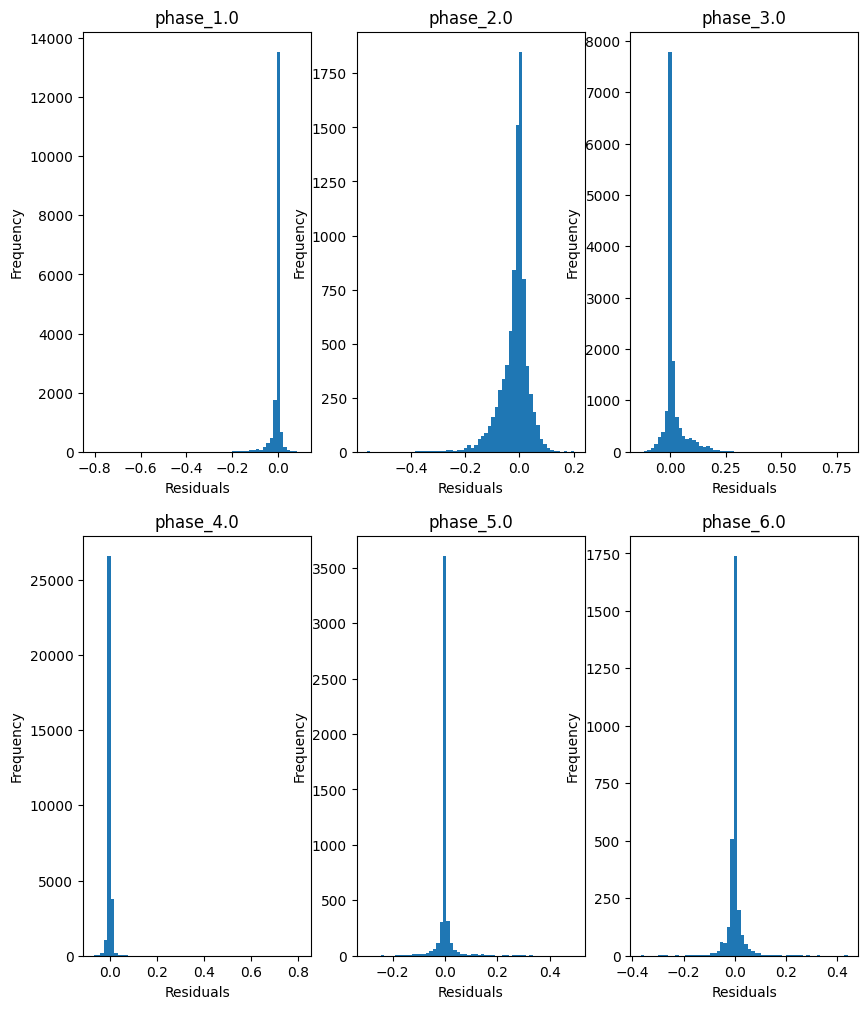

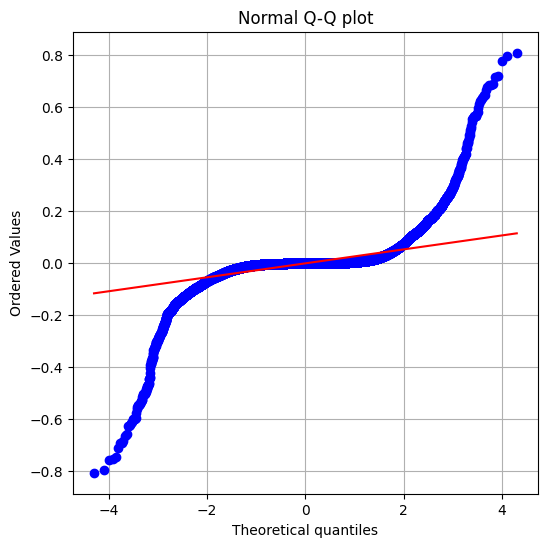

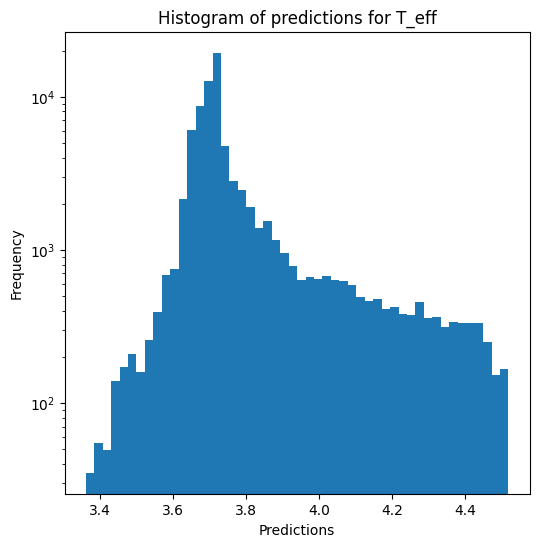

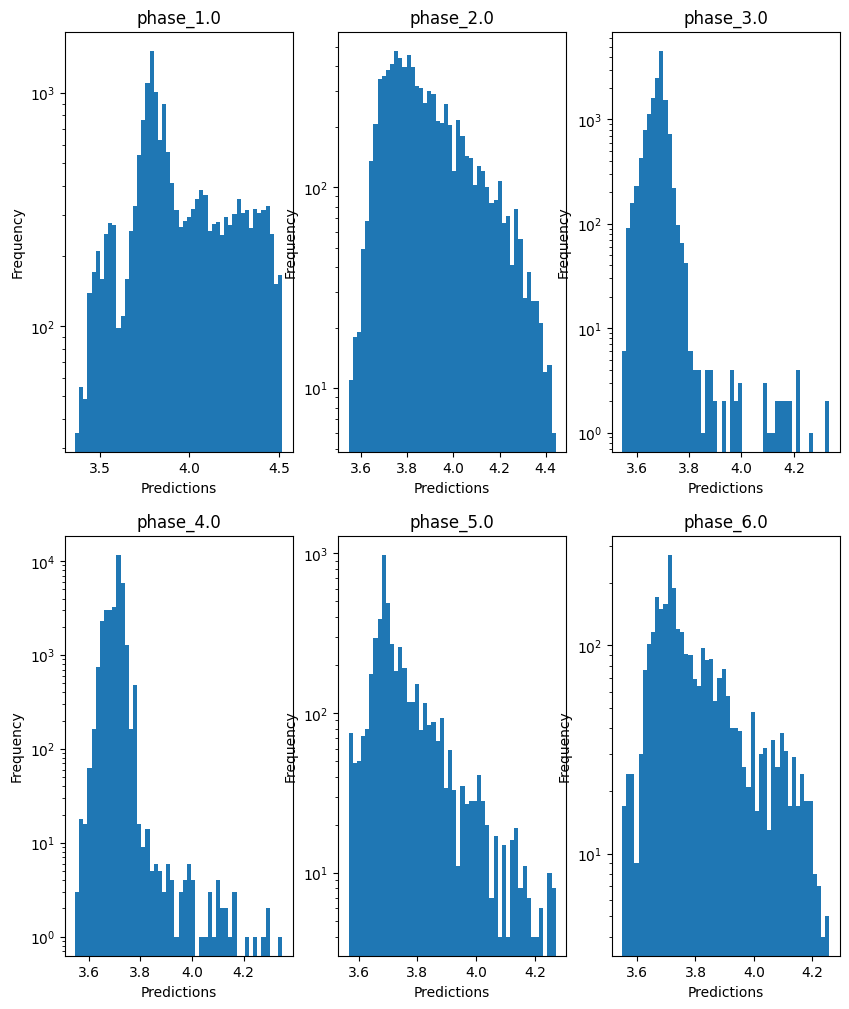

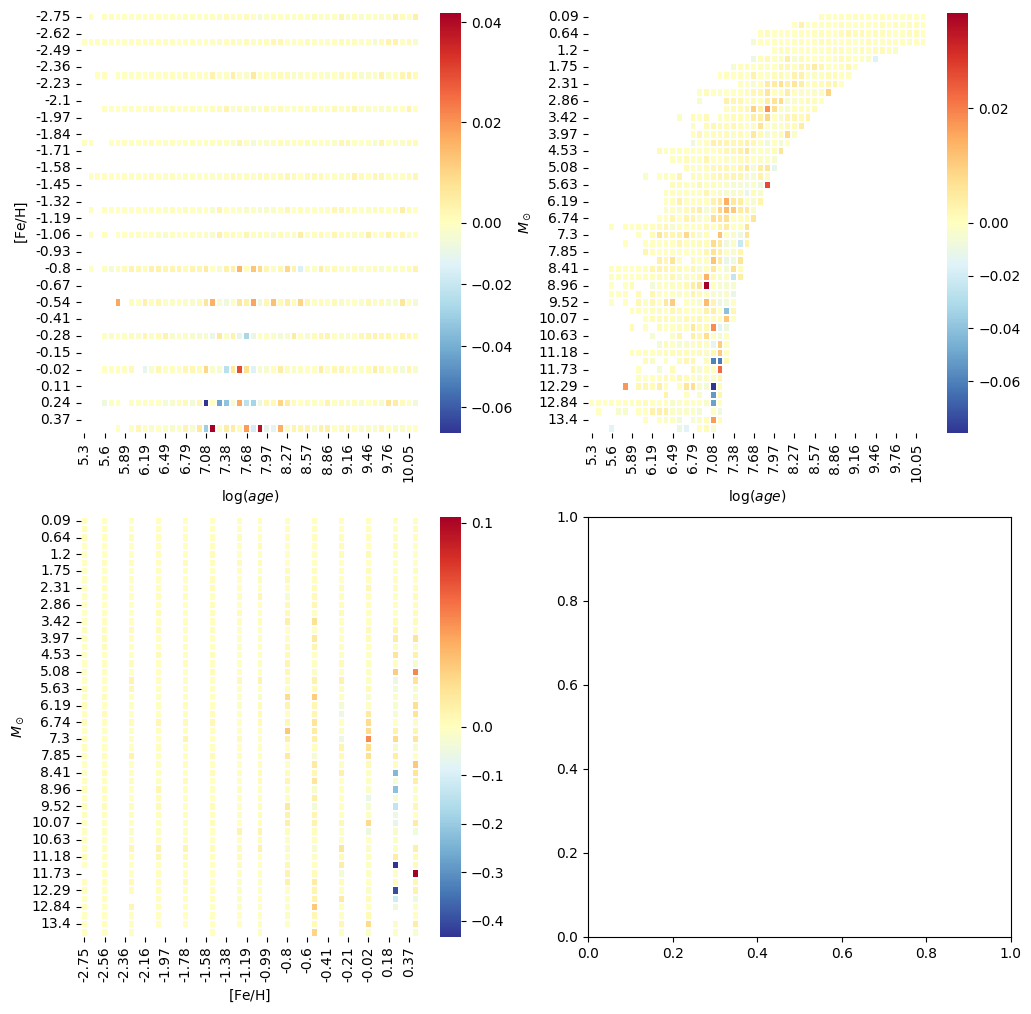

0.0

log_g results for the phase category with a value of 1.0
  value range :  3.241 - 5.345
  RVE :  0.1219791998887404
  RMSE :  0.3283111585244035
  MAE :  0.08241359797834054
  MedAE :  0.0034285714285715585
  CORR :  0.7685689125097879
  MAX_ER :  4.18
  Percentiles : 
    75th percentile :  0.016000000000000902
    90th percentile :  0.07109999999999954
    95th percentile :  0.5623071428571432
    99th percentile :  1.843652142857147

log_g results for the phase category with a value of 2.0
  value range :  0.672 - 4.266
  RVE :  0.5934599921322502
  RMSE :  0.5523405746557953
  MAE :  0.2745646874510244
  MedAE :  0.07457142857142784
  CORR :  0.7963781210344598
  MAX_ER :  3.2471111111111117
  Percentiles : 
    75th percentile :  0.22863798701298702
    90th percentile :  1.0253403846153843
    95th percentile :  1.402671122994652
    99th percentile :  2.114641999999999

log_g results for the phase category with a value of 3.0
  value range :  -0.347 - 3.787
  RVE :  -0.0166

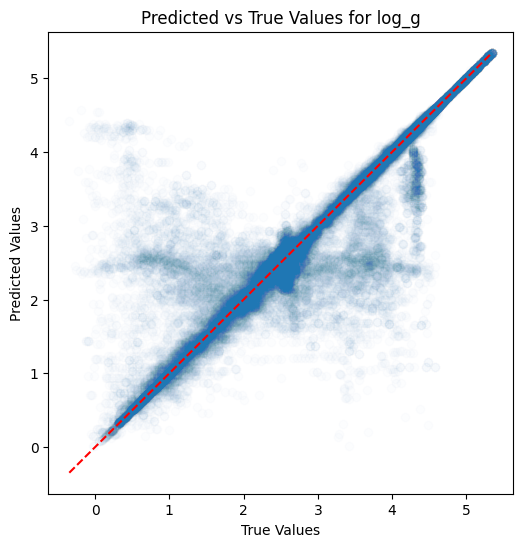

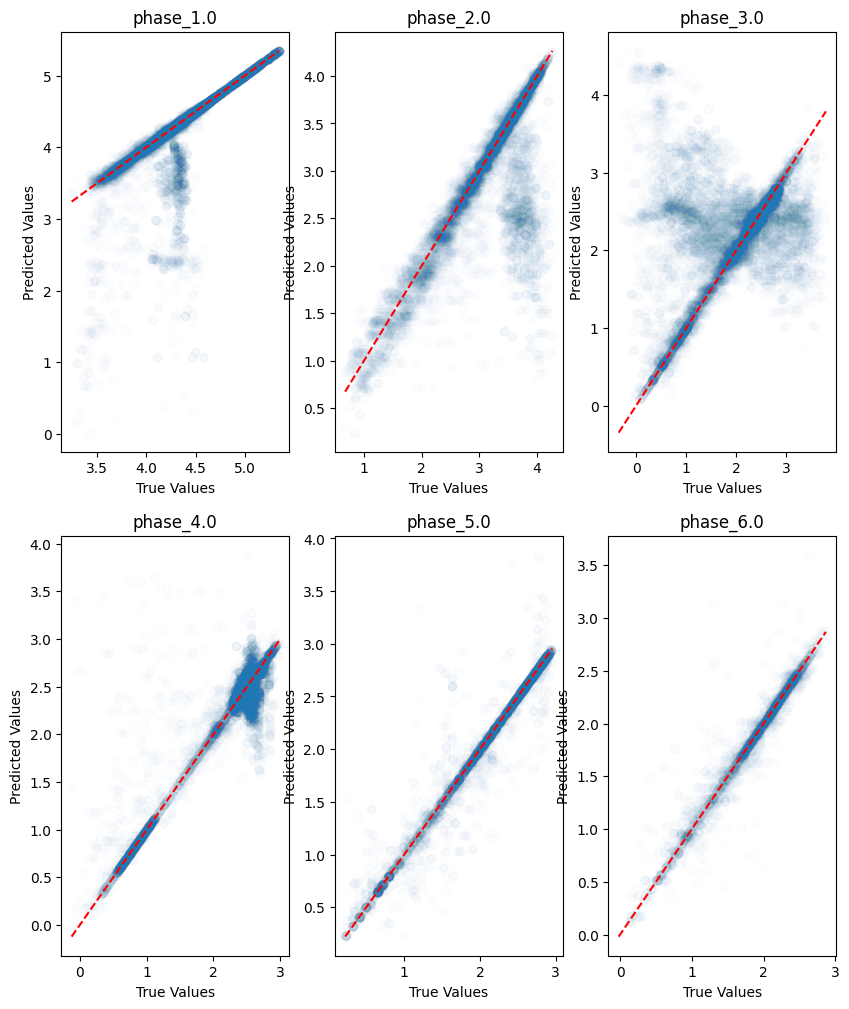

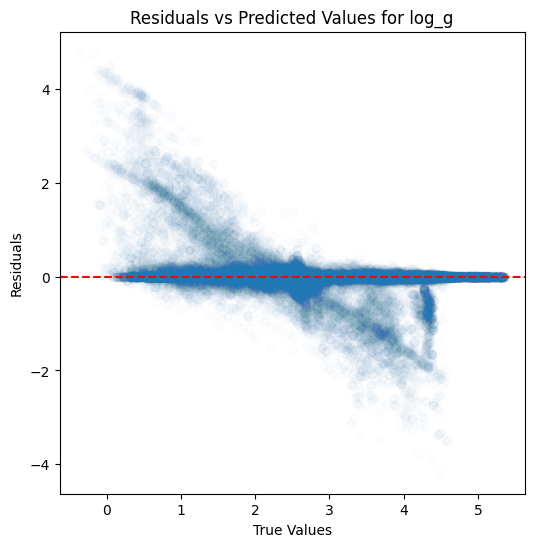

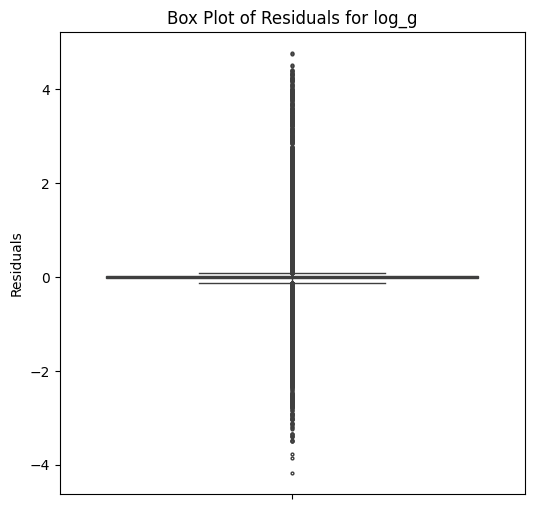

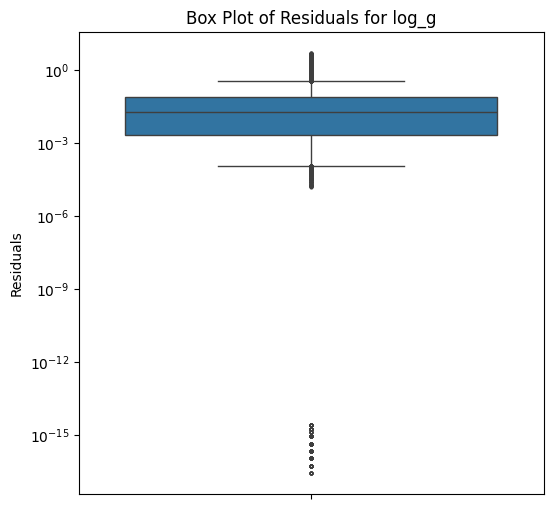

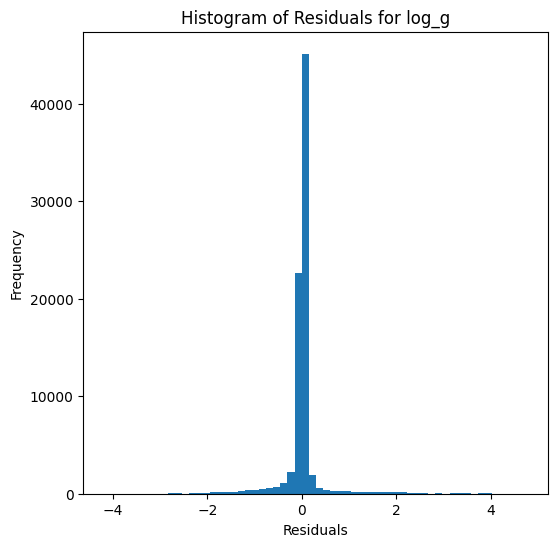

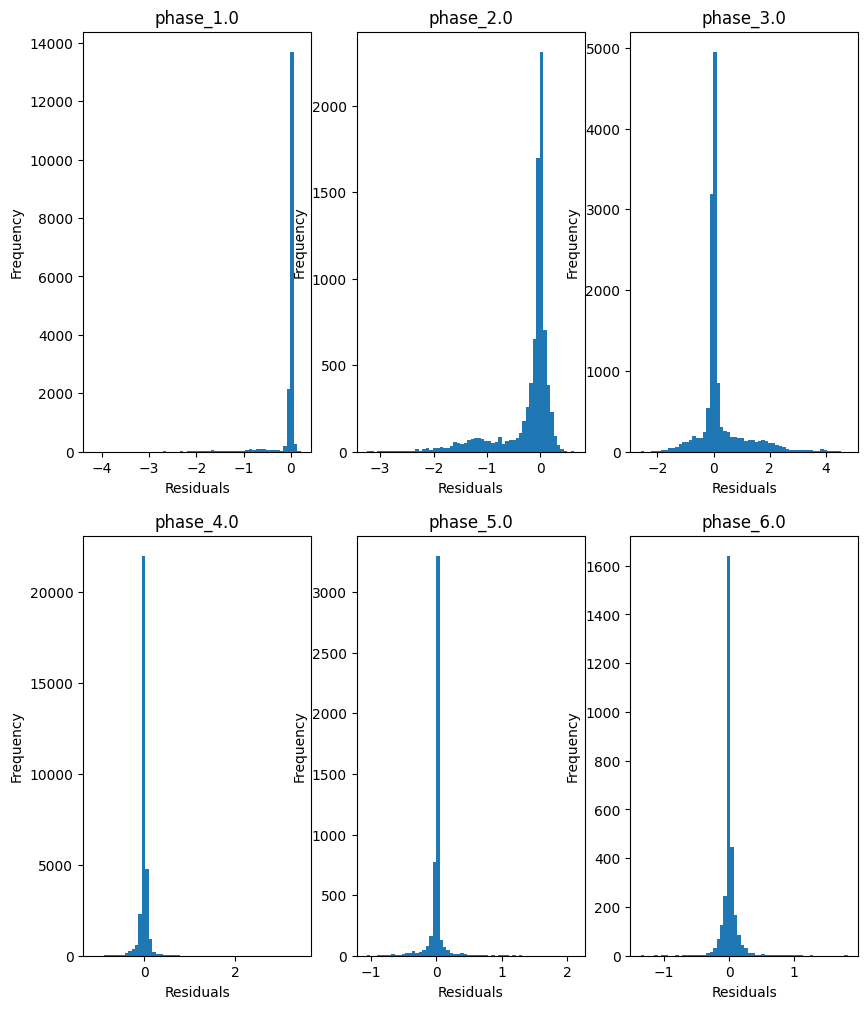

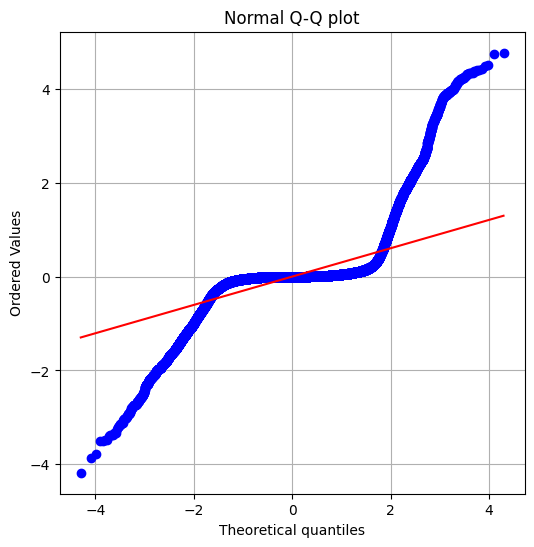

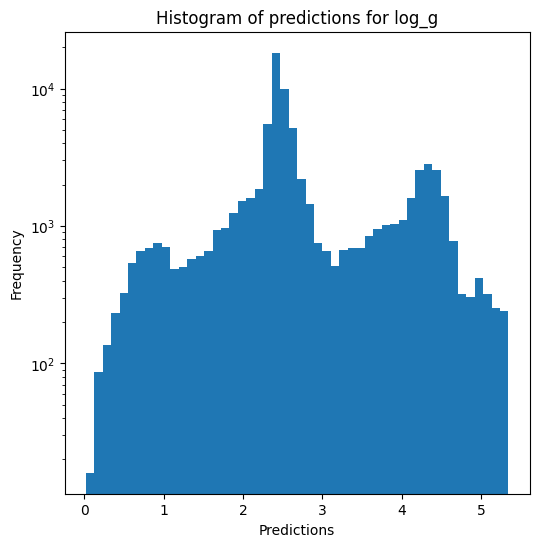

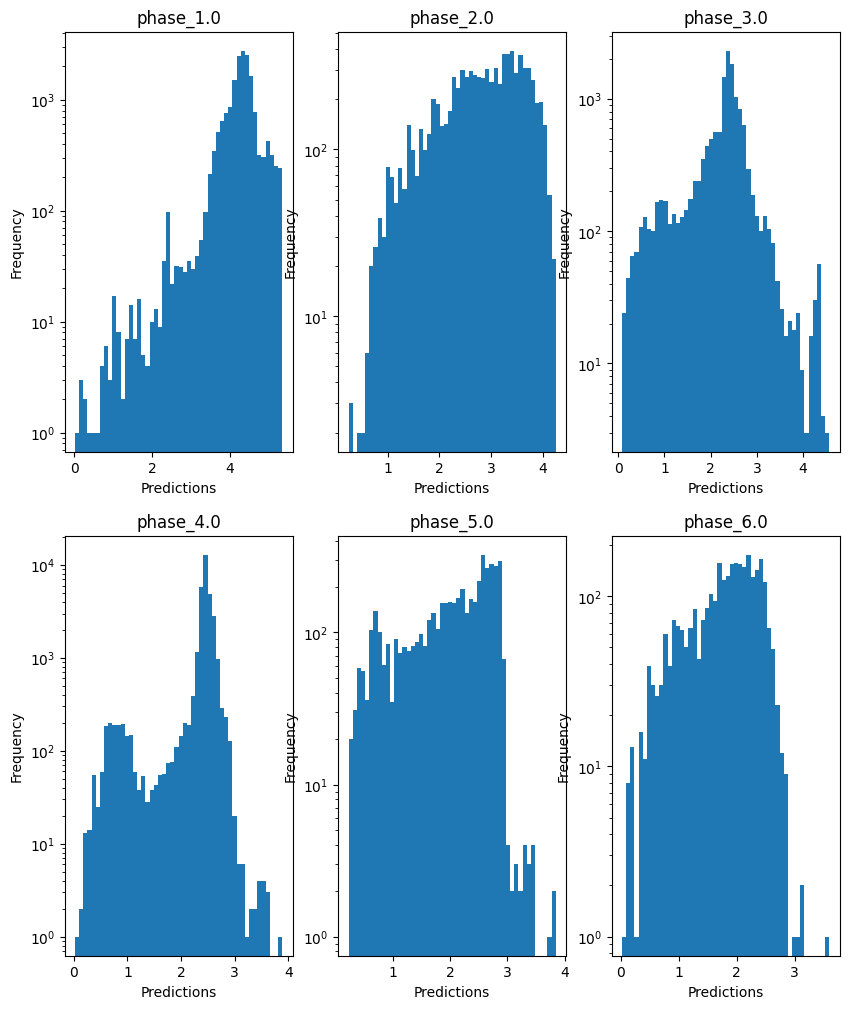

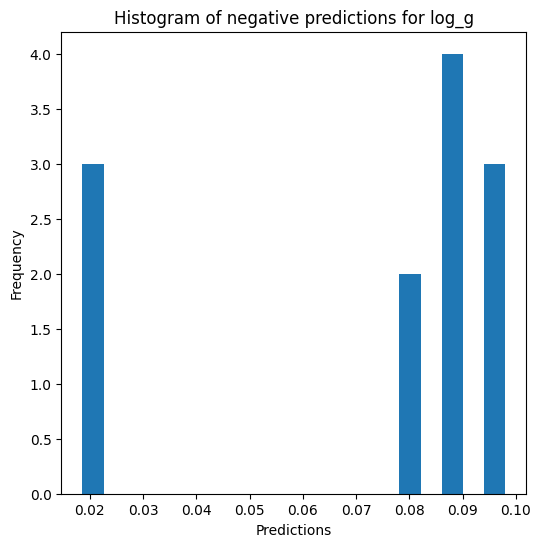

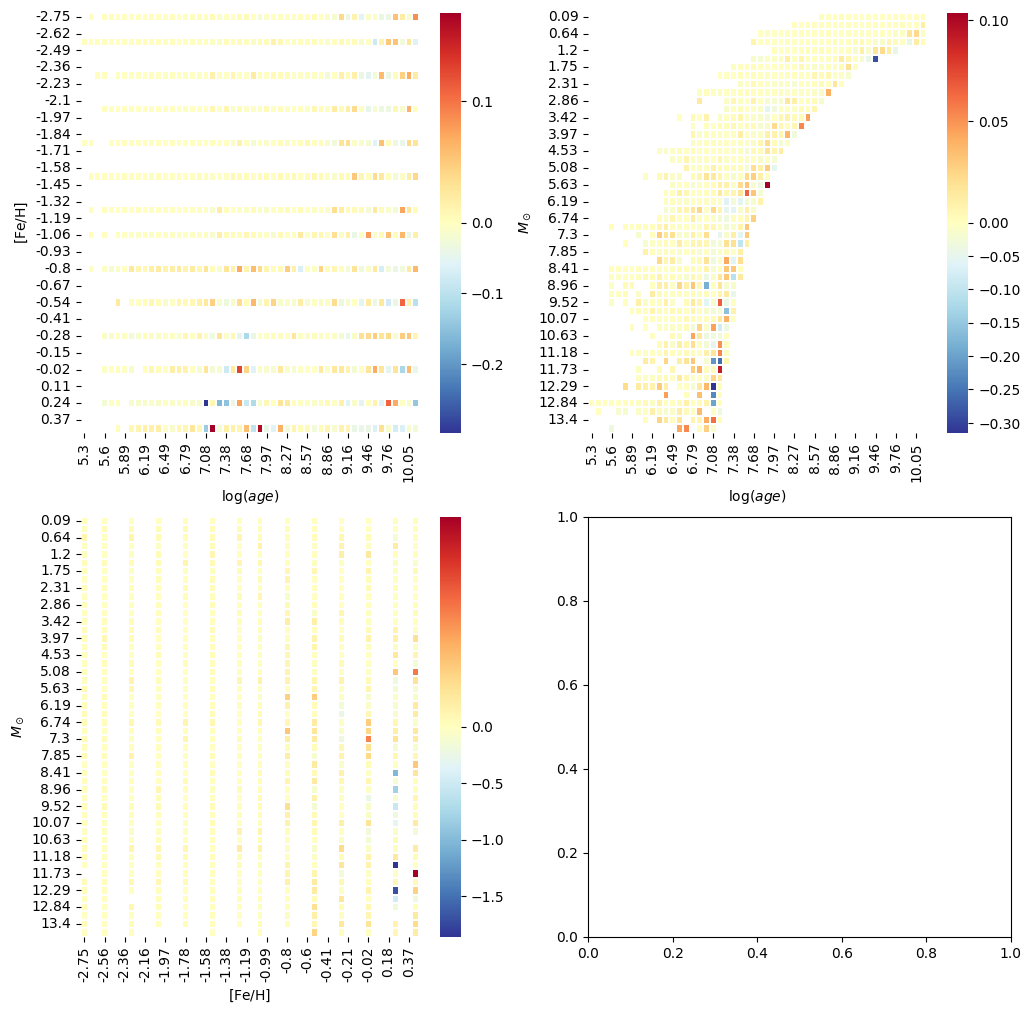

0.0

radius results for the phase category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.8092968313000649
  RMSE :  0.16493801974614275
  MAE :  0.04267817790184316
  MedAE :  0.0021859528275696705
  CORR :  0.9182759847354075
  MAX_ER :  2.090872933956464
  Percentiles : 
    75th percentile :  0.010613428263264425
    90th percentile :  0.04373047796822416
    95th percentile :  0.2810687916544674
    99th percentile :  0.9219174748389858

radius results for the phase category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.7784843871721154
  RMSE :  0.27619015811876013
  MAE :  0.1373451599283384
  MedAE :  0.03753010550708624
  CORR :  0.8835455717339531
  MAX_ER :  1.6219379657090225
  Percentiles : 
    75th percentile :  0.11421580577057083
    90th percentile :  0.5125249453715152
    95th percentile :  0.701388214366825
    99th percentile :  1.057853078351966

radius results for the phase categor

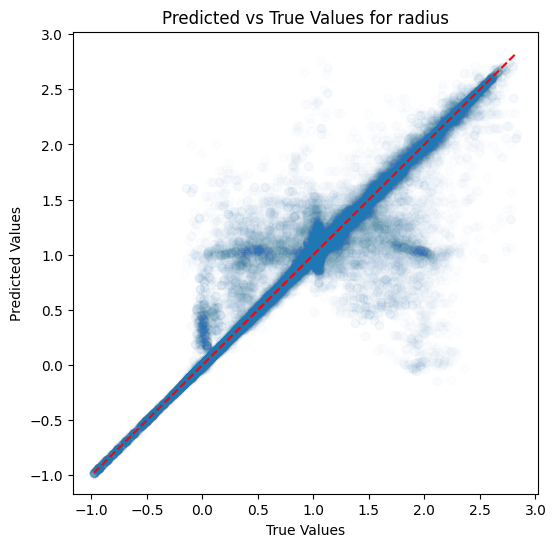

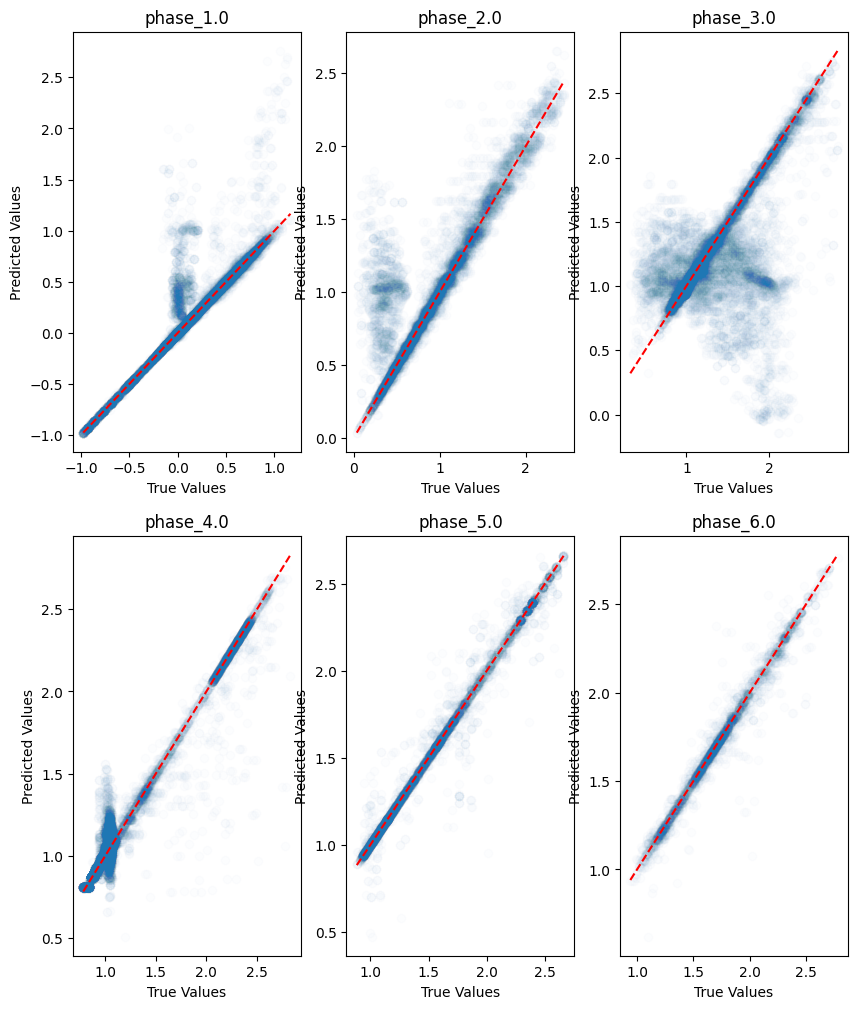

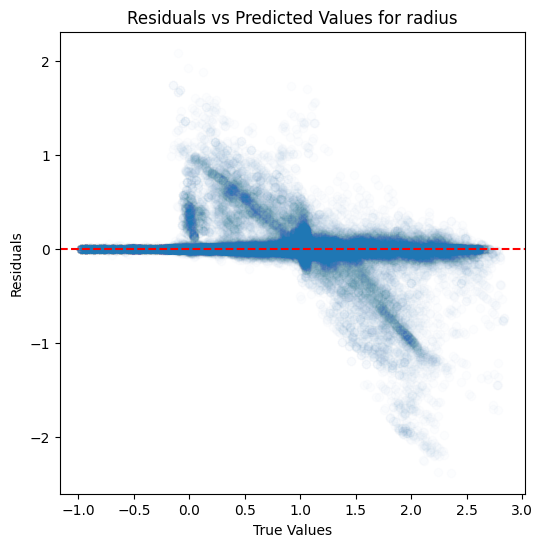

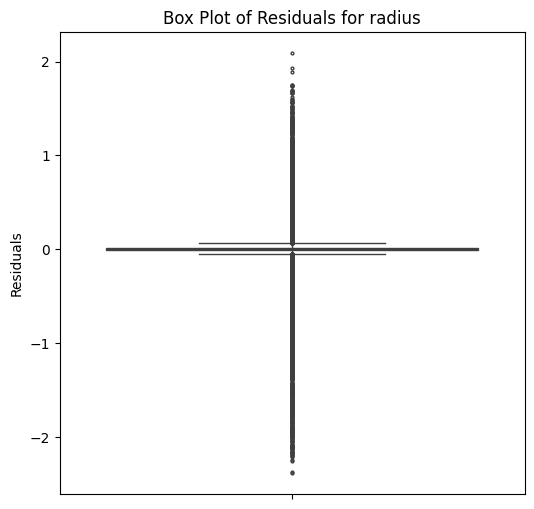

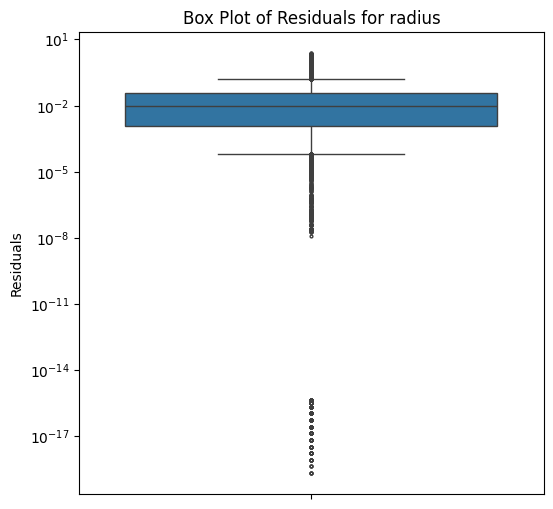

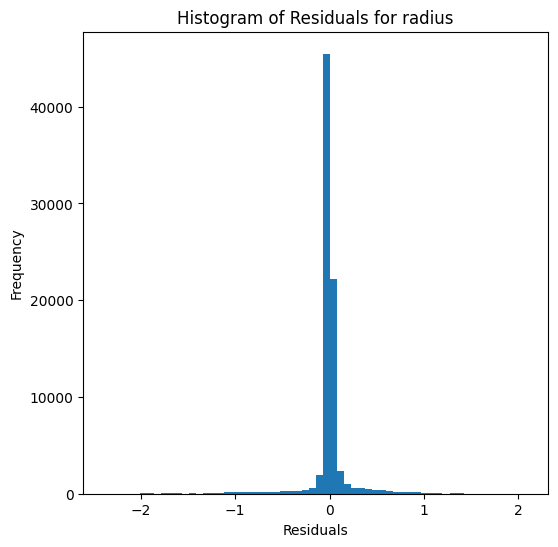

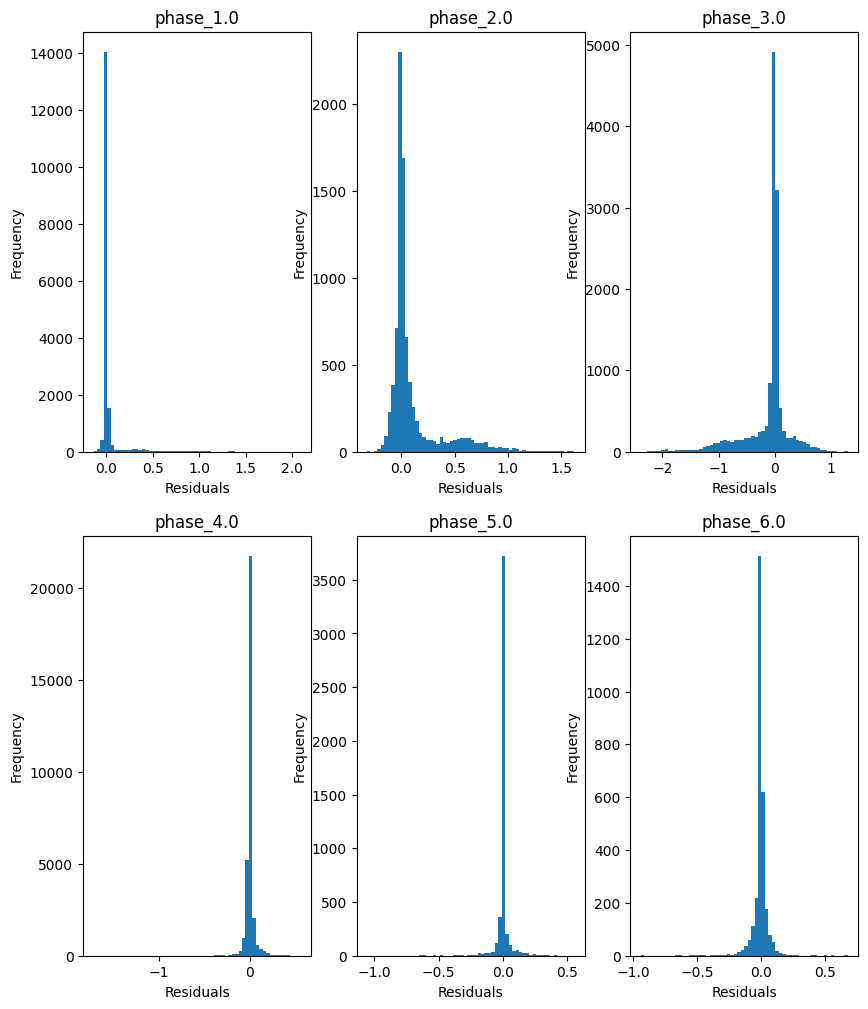

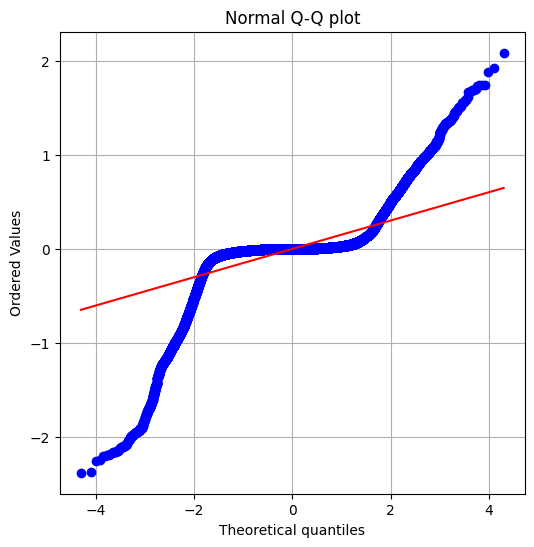

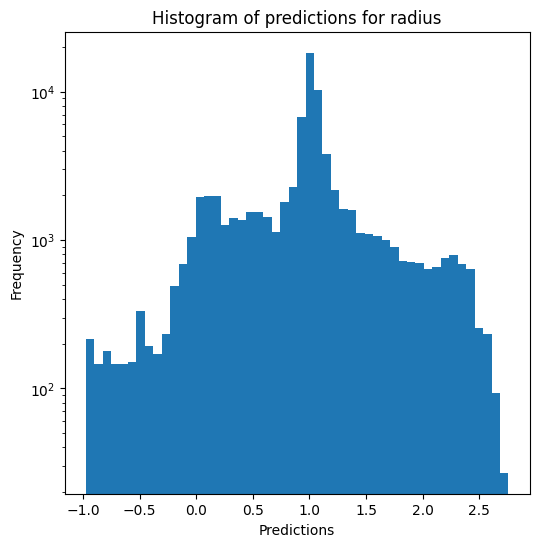

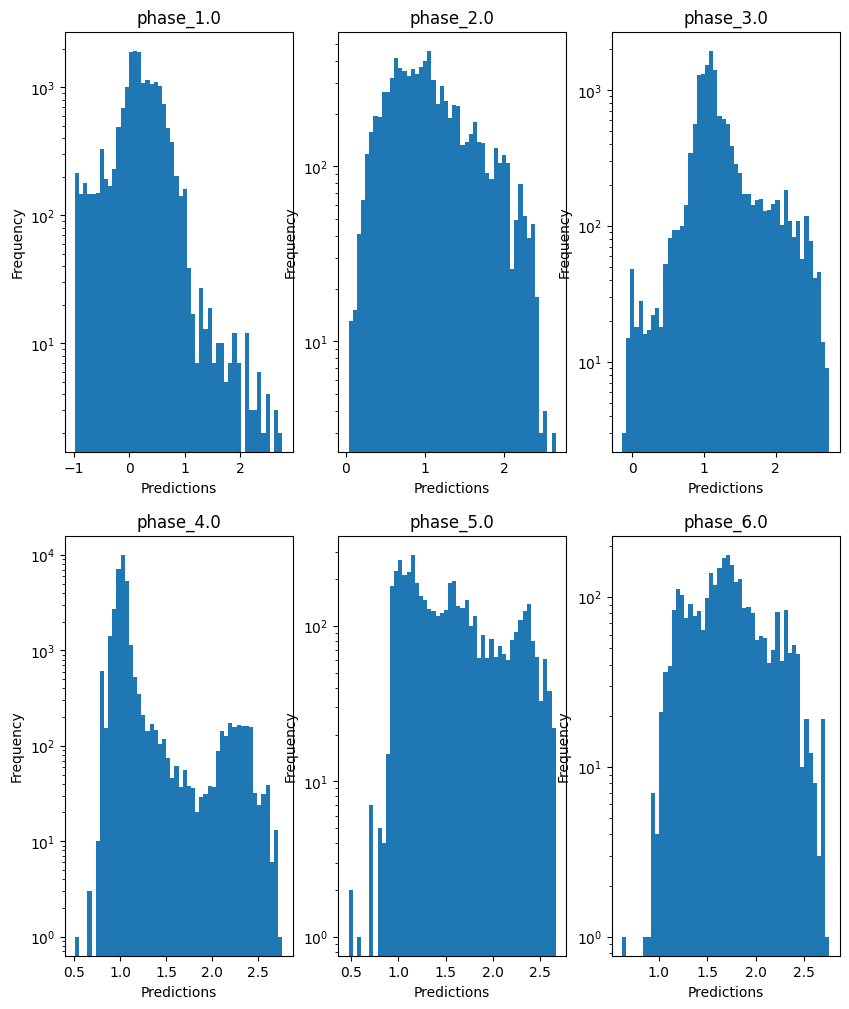

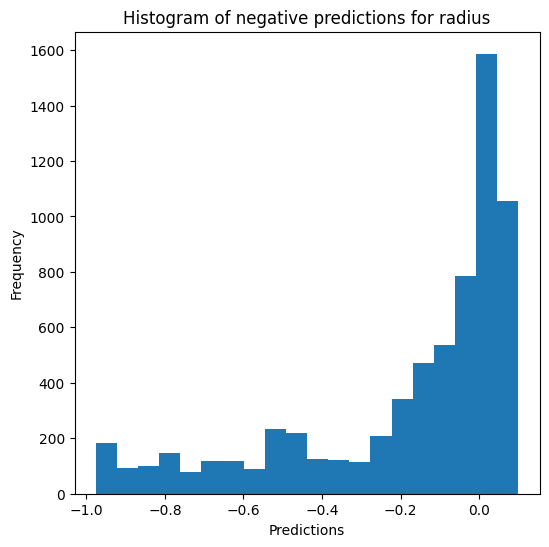

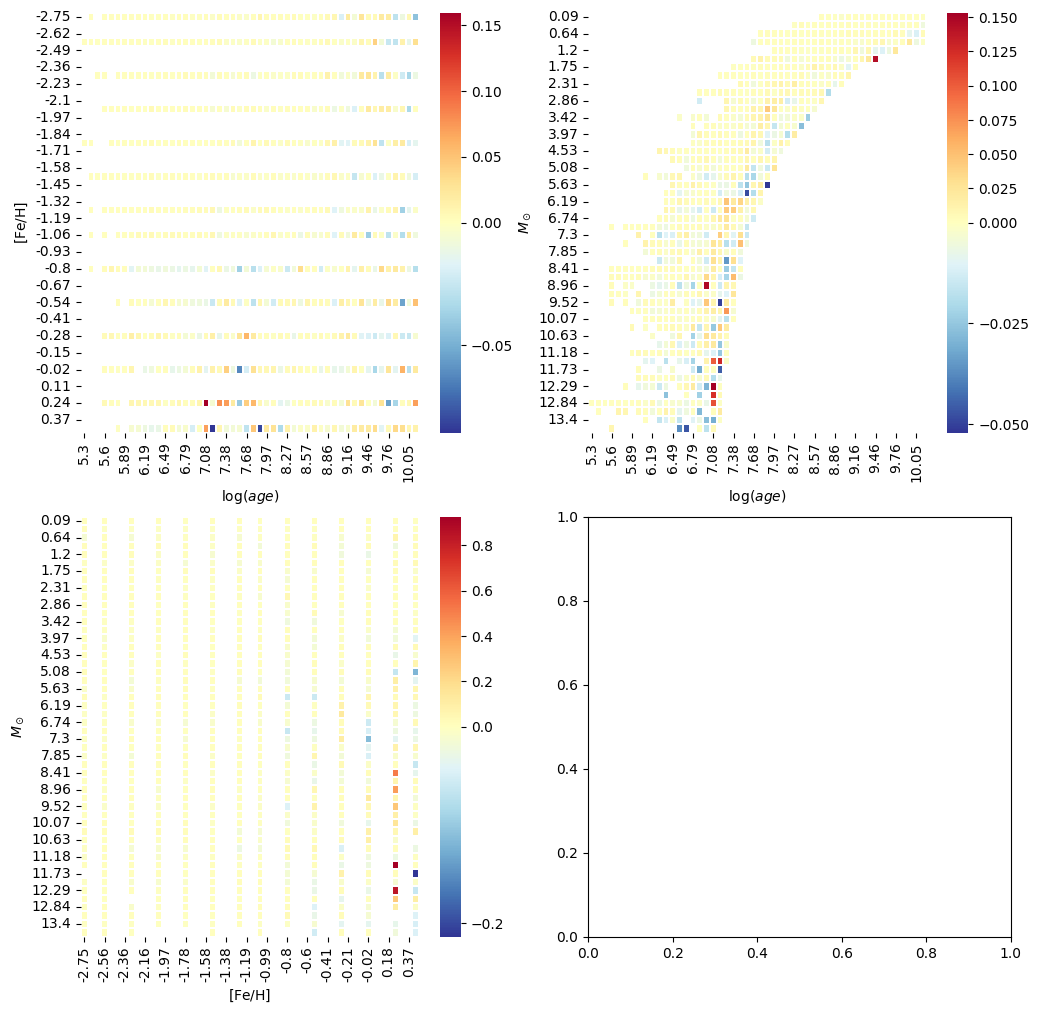

Saving predictions and results...


In [15]:
best_params_DT = {'criterion': 'friedman_mse', 'splitter': "best", 'max_depth': 75, 'min_samples_leaf': 5, 'min_samples_split': 4, 'max_features': None, 'max_leaf_nodes': None}

print(path_to_results)
evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(DecisionTreeRegressor, X_train_power, X_ivs_power, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=override, use_preds=use_preds, save=save, show=show, 
                               inputs=X_ivs, inputs_col_names=input_col_names, output_col_names=output_col_names, **best_params_DT)

# Training the final models

In [9]:
X = np.append(X_train, X_ivs, 0)
X_quantile = np.append(X_train_quantile, X_ivs_quantile, 0)
X_power = np.append(X_train_power, X_ivs_power, 0)
y = np.append(y_train, y_ivs, 0)

print(X.shape)
print(X_quantile.shape)
print(X_power.shape)
print(y.shape)

(321696, 3)
(321696, 3)
(321696, 3)
(321696, 3)


## Random forest

In [18]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 3, 'min_samples_split': 10, 'max_features': None, 'max_leaf_nodes': None}

mdl = RandomForestRegressor(**best_params_RF)
mdl.fit(X_quantile, y)

,n_estimators,300
,criterion,'friedman_mse'
,max_depth,50
,min_samples_split,10
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "RF_compress_3.pkl", compress=3)
# 500 MB
# 22.2 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/PARSEC/RF_compress_3.pkl']

## KNN

In [10]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'ball_tree', 'leaf_size': 75, 'n_neighbors': 10, 'weights': 'uniform'}

mdl = KNeighborsRegressor(**best_params_KNN)
mdl.fit(X_power, y)

,n_neighbors,10
,weights,'uniform'
,algorithm,'ball_tree'
,leaf_size,75
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,10


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "KNN_compress_0.pkl", compress=0)
# 25 MB
# 0.0 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/PARSEC/KNN_compress_0.pkl']

## Decision tree

In [12]:
best_params_DT = {'criterion': 'friedman_mse', 'splitter': "best", 'max_depth': 75, 'min_samples_leaf': 5, 'min_samples_split': 4, 'max_features': None, 'max_leaf_nodes': None}

mdl = DecisionTreeRegressor(**best_params_DT)
mdl.fit(X_power, y)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,75
,min_samples_split,4
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "DT_compress_0.pkl", compress=0)
# 4.9 MB
# 0.0 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/PARSEC/DT_compress_0.pkl']